# Valorisation prospective d'un Support à Formule — Méthode LSMC
## Least Squares Monte Carlo (Longstaff–Schwartz adapté)

---

**Objectif de ce notebook :**  
Estimer la distribution de la valeur de marché future $\text{VM}_1$ d'un Support à Formule (produit structuré autocall) à l'horizon $t = 1$ an, dans le cadre de l'**ORSA / business planning Solvabilité II**.

**Produit étudié :** Support à Formule (autocall) — caractéristiques lues depuis `Data.xlsx`

**Plan du notebook (réorganisé) :**
1. Imports et configuration
2. Lecture des données (`Data.xlsx`)
3. Fonctions cœur : `simulate_gbm_monthly`, `decrement_paths`, `Payoff`, `VM`
4. Extraction des paramètres du produit
5. Valorisation VM₀ (référence) + visualisation des trajectoires
6. Analyse de sensibilité de VM₀ à S₀ (delta, élasticité, écarts vs approximation linéaire)
7. Figure pédagogique — structure du payoff à maturité
8. Problématique de la valorisation prospective VM₁
9. Figure pédagogique — principe de la méthode LSMC
10. Algorithme LSMC — implémentation pas-à-pas (4 étapes)
11. Fonctions réutilisables (packagées pour appliquer la méthode à n'importe quel produit)
12. Application : calibration LSMC sur le produit étudié + résultats
13. Validation du modèle sur le portefeuille (37 produits)


---
## Section 1 — Imports et configuration

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from dataclasses import dataclass
from typing import Optional, Literal, Dict, Tuple, Any

# Reproductibilité globale
SEED_OUTER = 42
SEED_INNER = 123

print("✓ Imports OK")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")


✓ Imports OK
  numpy  2.1.3
  pandas 2.2.3


---
## Section 2 — Lecture des données (`Data.xlsx`)

Le fichier `Data.xlsx` contient :
- **Sheet `Feuil1`** : caractéristiques contractuelles du produit (une ligne = un produit)
- **Sheet `Taux`** : courbe des taux zéro-coupon (colonnes `Year` et `Taux`)
- **Sheet `EUROSTOXX`** (ou `Data`) : historique de l'indice sous-jacent (col A = date, col B = niveau)

> **Note :** Le notebook est conçu pour travailler sur **un seul produit** sélectionné par son `Libellé`.  
> Modifiez la variable `PRODUIT_LIBELLE` pour changer de produit.


In [0]:
# ─── Chemin vers le fichier Excel ────────────────────────────────────
XLSX_PATH = "Data.xlsx"          # ← modifiez si nécessaire

# ─── Sélection du produit à analyser ─────────────────────────────────
# PRODUIT_LIBELLE = None                            # None = prendre le premier produit disponible


PRODUIT_LIBELLE = "MMA Elite Mai 2025"
                                 # Modifiez ici pour sélectionner un autre produit du portefeuille

# ─── Lecture des sheets ───────────────────────────────────────────────
import pandas as pd
import sys

!pip install openpyxl
products_df = pd.read_excel(XLSX_PATH, sheet_name="Feuil1")


taux_df     = pd.read_excel(XLSX_PATH, sheet_name="Taux")

print(f"✓ {len(products_df)} produit(s) chargé(s) depuis Feuil1")
print(f"✓ Courbe des taux : {len(taux_df)} points")
print()
print("Colonnes disponibles dans Feuil1 :")
print(list(products_df.columns))


Looking in indexes: https://pypi.org/simple, https://****@pkgs.dev.azure.com/claud-ia/packagefactory/_packaging/snapshot/pypi/simple/, https://****@pkgs.dev.azure.com/claud-ia/packagefactory/_packaging/claudia-sdk-for-python/pypi/simple/
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
✓ 49 produit(s) chargé(s) depuis Feuil1
✓ Courbe des taux : 150 points

Colonnes disponibles dans Feuil1 :
['Unnamed: 0', 'Libellé', 'Date debut', 'Valeur Debut', 'Date valuation', 'Valeur à date valuation', 'S0', 'Barriere sortie anticipé', 'Barriere sortie maturité', 'Barriere protection', 'freq sortie', 'coupon par periode', 'premiere annee sortie', 'Annee finale', 'valeur liquidative', 'vm THEORIQUE', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'St2026', 2026, 2027, 'Unnamed: 23', 'Unnamed: 24']


In [0]:
# ─── Affichage de la courbe des taux ─────────────────────────────────
print("Courbe des taux (extrait) :")
print(taux_df.head(10).to_string(index=False))


Courbe des taux (extrait) :
 Year    Taux
    1 0.02236
    2 0.02093
    3 0.02093
    4 0.02120
    5 0.02142
    6 0.02170
    7 0.02198
    8 0.02222
    9 0.02243
   10 0.02267


In [0]:
# ─── Sélection du produit ─────────────────────────────────────────────
if PRODUIT_LIBELLE is None:
    row = products_df.dropna(subset=["S0"]).iloc[0]
else:
    mask = products_df["Libellé"].astype(str).str.strip() == PRODUIT_LIBELLE
    if not mask.any():
        raise ValueError(f"Produit '{PRODUIT_LIBELLE}' introuvable. Libellés disponibles : {list(products_df['Libellé'])}")
    row = products_df[mask].iloc[0]

print(f"✓ Produit sélectionné : {row['Libellé']}")
print()
print(row.to_string())


✓ Produit sélectionné : MMA Elite Mai 2025

Unnamed: 0                                   44
Libellé                      MMA Elite Mai 2025
Date debut                  2025-08-08 00:00:00
Valeur Debut                             957.01
Date valuation              2025-12-31 00:00:00
Valeur à date valuation                 1030.95
S0                                  1077.261471
Barriere sortie anticipé                   0.87
Barriere sortie maturité                    0.6
Barriere protection                         0.6
freq sortie                       trimestrielle
coupon par periode                        0.019
premiere annee sortie                         2
Annee finale                                 10
valeur liquidative                       103.79
vm THEORIQUE                         104.185873
Unnamed: 16                                 NaN
Unnamed: 17                            0.395873
Unnamed: 18                              0.0038
Unnamed: 19                                 

---
## Section 3 — Fonctions du code original (inchangées)

Ces fonctions sont **identiques** au code original `saf_model.py`.  
Elles sont reproduites ici pour que le notebook soit **autonome** (standalone).

> `simulate_gbm_monthly` · `decrement_paths` · `Payoff` · `VM`


### 3.1 — Types et helpers

In [0]:
FreqSortie    = Literal["mensuelle", "trimestrielle", "semestrielle", "annuelle"]
DecrementMode = Literal["flat", "cum"]
Compounding   = Literal["annual", "cc"]

@dataclass
class BSParams:
    r_annual_cc:  float
    sigma_annual: float
    s0:           float
    s0_date:      Optional[pd.Timestamp]

# ── Helpers de parsing ────────────────────────────────────────────────
def _freq_to_months(freq: FreqSortie) -> int:
    return {"mensuelle": 1, "trimestrielle": 3, "semestrielle": 6, "annuelle": 12}[freq]

def _map_to_next_grid(theo_dates, grid):
    mapped = []
    for d in theo_dates:
        pos = grid.searchsorted(d, side="left")
        if pos < len(grid):
            mapped.append(grid[pos])
    return mapped

def _parse_ratio(x):
    if pd.isna(x): raise ValueError("ratio manquant")
    s = str(x).strip().replace(" ", "").replace(",", ".")
    if s.endswith("%"): return float(s[:-1]) / 100.0
    v = float(s)
    return v / 100.0 if v > 1.0 else v

def _parse_float(x, name):
    if pd.isna(x): raise ValueError(f"{name} manquant")
    return float(str(x).strip().replace(",", "."))

def _parse_int(x, name):
    return int(float(str(x).strip().replace(",", ".")))

def _normalize_freq(f):
    if pd.isna(f): return None
    m = {"mensuelle":"mensuelle","mensuel":"mensuelle","monthly":"mensuelle",
         "trimestrielle":"trimestrielle","trimestriel":"trimestrielle","quarterly":"trimestrielle",
         "semestrielle":"semestrielle","semiannual":"semestrielle",
         "annuelle":"annuelle","annuel":"annuelle","annual":"annuelle","yearly":"annuelle"}
    return m.get(str(f).strip().lower(), None)

def _months_to_reach(v_date, m_date):
    v, m = pd.Timestamp(v_date), pd.Timestamp(m_date)
    if m <= v: return 1
    months = (m.year - v.year)*12 + (m.month - v.month)
    if m.day > v.day: months += 1
    return int(max(1, months + 2))

print("✓ Types et helpers définis")


✓ Types et helpers définis


### 3.2 — `simulate_gbm_monthly` — Simulation GBM mensuelle

**Modèle Black-Scholes (mesure risque-neutre Q) :**

$$S_{t+\Delta t} = S_t \cdot \exp\!\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\, Z\right], \quad Z \sim \mathcal{N}(0,1), \quad \Delta t = \frac{1}{12}$$

- Output : DataFrame de forme `(n_sims, n_months+1)`, colonnes = dates mensuelles
- La **colonne 0** correspond à la date de départ avec valeur $S_0$


In [0]:
def simulate_gbm_monthly(
    s0: float,
    r_annual_cc: float,
    sigma_annual: float,
    start_date: str,
    n_months: int,
    n_sims: int,
    seed: Optional[int] = 42,
) -> pd.DataFrame:
    """
    Simulation GBM mensuelle — code original inchangé (sauf freq ME).
    Output : DataFrame (n_sims × n_months+1), colonnes = DatetimeIndex mensuel.
    """
    rng = np.random.default_rng(seed)
    dt  = 1.0 / 12.0
    # FIX : "ME" remplace "M" (deprecated pandas 2.2+)
    dates = pd.date_range(start=pd.Timestamp(start_date), periods=n_months + 1, freq="ME")

    Z         = rng.standard_normal(size=(n_months, n_sims))
    drift     = (r_annual_cc - 0.5 * sigma_annual**2) * dt
    diffusion = sigma_annual * np.sqrt(dt) * Z

    log_paths = np.vstack([np.zeros((1, n_sims)), np.cumsum(drift + diffusion, axis=0)])
    paths     = s0 * np.exp(log_paths)

    df = pd.DataFrame(paths.T, index=np.arange(1, n_sims + 1), columns=dates)
    df.index.name = "scenario"
    return df




### 3.3 — `decrement_paths` — Décrement de l'indice

Le décrement représente le **dividende estimé** détaché de l'indice.

Avec `mode="cum"` et `offset_periods=k₀` :

$$\text{dec}(k) = \left(k_0 + k\right) \times \frac{\text{decrement\_value}}{\text{periods\_per\_year}}$$

Le paramètre `offset_periods` est **nouveau** par rapport au code original.  
Il sera utilisé dans le LSMC pour continuer le décrement depuis $t=1$ (et non le remettre à zéro).


In [0]:
def decrement_paths(
    df: pd.DataFrame,
    decrement_value: float = 50.0,
    periods_per_year: int = 12,
    mode: DecrementMode = "cum",
    offset_periods: int = 0,       # NOUVEAU : nb de périodes déjà écoulées
) -> pd.DataFrame:
    """
    Décrement linéaire des trajectoires simulées.

    offset_periods=0  → comportement original (VM₀)
    offset_periods=12 → pour inner paths LSMC (continuer depuis t=1 an)

    Exemple mode='cum', monthly, offset=0 :
      col 0 → 0,  col 1 → -50/12,  col k → -k×50/12
    Exemple mode='cum', monthly, offset=12 :
      col 0 → -50,  col 1 → -13×50/12,  ...
    """
    df_dec = df.copy()
    cols   = pd.to_datetime(df_dec.columns)
    order  = np.argsort(cols.values)
    df_dec = df_dec.iloc[:, order]

    n_cols = df_dec.shape[1]
    if n_cols == 0:
        return df_dec

    per_period = float(decrement_value) / float(periods_per_year)
    k          = np.arange(n_cols, dtype=float) + float(offset_periods)

    if mode == "flat":
        decrements = per_period * (k > 0)
    elif mode == "cum":
        decrements = per_period * k
    else:
        raise ValueError("mode doit être 'flat' ou 'cum'")

    df_dec.iloc[:, :] = df_dec.values - decrements
    return df_dec

# print("✓ decrement_paths définie (avec paramètre offset_periods)")


### 3.4 — `Payoff` — Calcul vectorisé du payoff contractuel

**Structure payoff du Support à Formule :**

| Événement | Condition | Payoff |
|---|---|---|
| Remboursement anticipé | $S_t / S_{\text{ref}} \geq B_{\text{autocall}}$ à une date d'observation | $S_{\text{ref}} \times (1 + c \times N)$ |
| Maturité Zone 1 | $S_T / S_{\text{ref}} \geq B_{\text{final}}$ | $S_{\text{ref}} \times (1 + c \times N)$ |
| Maturité Zone 2 | $B_{\text{protection}} \leq S_T / S_{\text{ref}} < B_{\text{final}}$ | $S_{\text{ref}}$ |
| Maturité Zone 3 | $S_T / S_{\text{ref}} < B_{\text{protection}}$ | $S_{\text{ref}} \times (S_T / S_{\text{ref}})$ |

où $c$ = coupon par période, $N$ = nombre de périodes écoulées, $S_{\text{ref}}$ = niveau de référence contractuel (= 1000).


In [0]:
def Payoff(
    paths: pd.DataFrame,
    date_debut: str | pd.Timestamp,
    s_ref: float,
    barriere_sortie_anticipe: float,
    barriere_sortie_maturite: float,
    barriere_protection: float,
    premiere_annee_sortie: int,
    freq_sortie: FreqSortie,
    coupon_par_periode: float,
    annee_finale: int,
    day_count: int = 365,
) -> pd.DataFrame:
    """
    Calcul vectorisé du payoff — code original inchangé.
    Input  : paths (scenarios × dates), paramètres contractuels
    Output : DataFrame avec colonnes Date_sortie, Payoff, Called, ...
    """
    if paths.shape[1] < 2:
        raise ValueError("paths doit avoir ≥ 2 colonnes.")

    df = paths.copy()
    df.columns = pd.to_datetime(df.columns)
    df = df.loc[:, sorted(df.columns)]
    grid  = pd.DatetimeIndex(df.columns)
    scen  = df.index

    val_date  = grid[0]
    d_debut   = pd.to_datetime(date_debut)
    S0_val    = df.iloc[:, 0].astype(float)
    step_m    = _freq_to_months(freq_sortie)

    # Calendrier d'observation théorique (anniversaire)
    start_obs = d_debut + pd.DateOffset(years=premiere_annee_sortie)
    mat_theo  = d_debut + pd.DateOffset(years=annee_finale)

    theo_dates, d, it = [], start_obs, 0
    while d <= mat_theo and it < 1000:
        theo_dates.append(d); d += pd.DateOffset(months=step_m); it += 1

    theo_dates = [d for d in theo_dates if d > val_date]

    mat_grid_list = _map_to_next_grid([mat_theo], grid)
    if not mat_grid_list:
        raise ValueError("Grid trop court pour atteindre la maturité.")
    mat_grid = mat_grid_list[0]

    def k_total(d_theo):
        md = (d_theo.year - d_debut.year)*12 + (d_theo.month - d_debut.month)
        return int(md // step_m)

    seen, pairs = set(), []
    for dt in theo_dates:
        pos = grid.searchsorted(dt, side="left")
        if pos < len(grid):
            dg = grid[pos]
            if dg <= mat_grid and dg not in seen:
                pairs.append((dt, dg)); seen.add(dg)

    # Initialisation : pas de sortie anticipée → maturité
    exit_date = pd.Series(mat_grid, index=scen, dtype="datetime64[ns]")
    called    = pd.Series(False, index=scen)
    nb_k      = pd.Series(k_total(mat_theo), index=scen, dtype=int)

    for dt, dg in pairs:
        if called.all(): break
        ratio = df[dg].astype(float) / float(s_ref)
        hit   = (ratio >= barriere_sortie_anticipe) & (~called)
        if hit.any():
            exit_date[hit] = dg
            nb_k[hit]      = k_total(dt)
            called[hit]    = True

    payoff = pd.Series(index=scen, dtype=float)
    sT = df[mat_grid].astype(float)
    rT = sT / float(s_ref)

    # Called
    payoff[called]  = float(s_ref) * (1.0 + coupon_par_periode * nb_k[called].astype(float))
    nc = ~called

    # Zone 1
    c1 = (rT >= barriere_sortie_maturite) & nc
    payoff[c1] = float(s_ref) * (1.0 + coupon_par_periode * nb_k[c1].astype(float))

    # Zone 2
    c2 = (rT >= barriere_protection) & (rT < barriere_sortie_maturite) & nc
    payoff[c2] = float(s_ref)

    # Zone 3
    c3 = (rT < barriere_protection) & nc
    payoff[c3] = float(s_ref) * rT[c3].astype(float)

    ratio_sortie = pd.Series(index=scen, dtype=float)
    for dg_u in exit_date.unique():
        m = (exit_date == dg_u)
        ratio_sortie[m] = (df.loc[m, dg_u].astype(float) / float(s_ref)).values

    T = (pd.to_datetime(exit_date) - pd.to_datetime(val_date)).dt.days.astype(float) / float(day_count)

    return pd.DataFrame({
        "Date_simulation": val_date, "Date_debut": d_debut,
        "S0_simulation": S0_val.values, "S_ref": float(s_ref),
        "Date_sortie": exit_date.values, "Ratio_sortie_S_sur_Sref": ratio_sortie.values,
        "Nb_periodes_total": nb_k.values, "Payoff": payoff.values, "Called": called.values,
    }, index=scen)




### 3.5 — `VM` — Valeur de marché par actualisation

$$\text{VM} = \frac{1}{P}\sum_{i=1}^{P} \text{Payoff}^{(i)} \cdot B(t_{\text{val}},\, t_{\text{sortie}}^{(i)})$$

où $B(t, T) = \dfrac{1}{(1+z_T)^{T-t}}$ avec $z_T$ = taux zéro-coupon interpolé à la maturité résiduelle $T-t$.


In [0]:
def VM(
    payoff_table: pd.DataFrame,
    courbe_taux: pd.DataFrame,
    date_valuation: str | pd.Timestamp,
    col_year: str = "Year",
    col_taux: str = "Taux",
    compounding: Compounding = "annual",
    day_count: int = 365,
) -> Tuple[pd.DataFrame, float]:
    """
    Calcule VM = moyenne des payoffs actualisés — code original inchangé.
    Règle : si Date_sortie ≤ date_valuation → PV = 0 (contrat éteint).
    """
    tbl = payoff_table.copy()
    date_valuation = pd.to_datetime(date_valuation)

    curve = courbe_taux[[col_year, col_taux]].dropna().copy()
    curve[col_year] = curve[col_year].astype(float)
    curve[col_taux] = curve[col_taux].astype(float)
    curve = curve.sort_values(col_year)
    x, y  = curve[col_year].values, curve[col_taux].values

    exit_dates = pd.to_datetime(tbl["Date_sortie"])
    payoff     = tbl["Payoff"].astype(float).values
    T          = (exit_dates - date_valuation).dt.days.astype(float) / float(day_count)

    alive  = T > 0
    T_pos  = np.where(alive, T, 0.0)
    T_clip = np.clip(T_pos, x.min(), x.max())
    z      = np.interp(T_clip, x, y)

    if compounding == "annual":
        df_fac = np.where(alive, 1.0 / np.power(1.0 + z, T_pos), 0.0)
    else:  # cc
        df_fac = np.where(alive, np.exp(-z * T_pos), 0.0)

    pv = np.where(alive, payoff * df_fac, 0.0)

    tbl["Date_valuation"]        = date_valuation
    tbl["T_en_annees"]           = T
    tbl["Alive_at_valuation"]    = alive
    tbl["Zero_rate_interp"]      = np.where(alive, z, np.nan)
    tbl["Facteur_actualisation"] = df_fac
    tbl["PV"]                    = pv

    return tbl, float(np.mean(pv))




---
## Section 4 — Extraction et validation des paramètres du produit

On extrait les caractéristiques contractuelles depuis la ligne sélectionnée dans `Data.xlsx`.


In [0]:
# ─── Paramètres contractuels ──────────────────────────────────────────
DATE_DEBUT              = pd.to_datetime(row["Date debut"])
S_REF                   = 1000.0          # niveau de référence contractuel (= Capital)
S0_T0                   = _parse_float(row["S0"], "S0")
BARRIERE_AUTOCALL       = _parse_ratio(row["Barriere sortie anticipé"])
BARRIERE_FINAL          = _parse_ratio(row["Barriere sortie maturité"])
BARRIERE_PROTECTION     = _parse_ratio(row["Barriere protection"])
PREMIERE_ANNEE_SORTIE   = _parse_int(row["premiere annee sortie"], "premiere annee sortie")
FREQ_SORTIE             = _normalize_freq(row["freq sortie"])
COUPON_PAR_PERIODE      = _parse_ratio(row["coupon par periode"])
ANNEE_FINALE            = _parse_int(row["Annee finale"], "Annee finale")

# ─── Paramètres de marché ─────────────────────────────────────────────
# R_NEUTRE_CC   = 0.0691009521484375   # taux sans risque annuel continu
R_NEUTRE_CC   = 0.0526   # taux sans risque annuel continu

SIGMA_ANNUAL  = 0.2120                 # volatilité annuelle (à ajuster)
MU_OUTER      = 0.0526                 # drift physique pour outer paths (ORSA)
DECREMENT_VAL = 50.0                 # points/an
DECREMENT_MODE = "cum"

# ─── Dates de valorisation ────────────────────────────────────────────
DATE_VAL_T0 = pd.Timestamp("2025-12-31")   # t₀ : date de valorisation initiale
DATE_VAL_T1 = pd.Timestamp("2026-12-31")   # t₁ = t₀ + 1 an

COMPOUNDING = "annual"
DAY_COUNT   = 365

print("✓ Paramètres extraits et validés")
print()
print(f"  Produit              : {row['Libellé']}")
print(f"  date_debut           : {DATE_DEBUT.date()}")
print(f"  S_ref (= Capital)    : {S_REF}")
print(f"  S₀(t₀)              : {S0_T0}")
print(f"  Barrière autocall    : {BARRIERE_AUTOCALL:.0%}  → niveau abs = {BARRIERE_AUTOCALL*S_REF:.0f}")
print(f"  Barrière finale      : {BARRIERE_FINAL:.0%}  → niveau abs = {BARRIERE_FINAL*S_REF:.0f}")
print(f"  Barrière protection  : {BARRIERE_PROTECTION:.0%}  → niveau abs = {BARRIERE_PROTECTION*S_REF:.0f}")
print(f"  1ère année autocall  : année {PREMIERE_ANNEE_SORTIE}")
print(f"  Fréquence observation: {FREQ_SORTIE}")
print(f"  Coupon / période     : {COUPON_PAR_PERIODE:.2%}")
print(f"  Maturité             : {ANNEE_FINALE} ans  → {(DATE_DEBUT + pd.DateOffset(years=ANNEE_FINALE)).date()}")
print()
print(f"  r (risque-neutre)    : {R_NEUTRE_CC:.4f}")
print(f"  σ (volatilité)       : {SIGMA_ANNUAL:.4f}")
print(f"  µ (physique ORSA)    : {MU_OUTER:.4f}")
print(f"  Décrement            : {DECREMENT_VAL} pts/an ({DECREMENT_MODE})")
print(f"  t₀ → t₁             : {DATE_VAL_T0.date()} → {DATE_VAL_T1.date()}")


✓ Paramètres extraits et validés

  Produit              : MMA Elite Mai 2025
  date_debut           : 2025-08-08
  S_ref (= Capital)    : 1000.0
  S₀(t₀)              : 1077.2614706220415
  Barrière autocall    : 87%  → niveau abs = 870
  Barrière finale      : 60%  → niveau abs = 600
  Barrière protection  : 60%  → niveau abs = 600
  1ère année autocall  : année 2
  Fréquence observation: trimestrielle
  Coupon / période     : 1.90%
  Maturité             : 10 ans  → 2035-08-08

  r (risque-neutre)    : 0.0526
  σ (volatilité)       : 0.2120
  µ (physique ORSA)    : 0.0526
  Décrement            : 50.0 pts/an (cum)
  t₀ → t₁             : 2025-12-31 → 2026-12-31


---
## Section 5 — Calcul de VM₀ (référence)

Avant de faire le LSMC, on calcule $\text{VM}_0$ avec le **code original** pour avoir une référence.

$$\text{VM}_0 = \mathbb{E}^Q\!\left[\sum_t \frac{\text{CF}_t}{B(0,t)}\right]$$


In [0]:
N_SIMS_VM0 = 10_000

print(f"Calcul VM₀ avec {N_SIMS_VM0:,} simulations...")

maturity_theo = DATE_DEBUT + pd.DateOffset(years=ANNEE_FINALE)
n_months_vm0  = _months_to_reach(DATE_VAL_T0, maturity_theo)

paths_vm0 = simulate_gbm_monthly(
    s0          = S0_T0,
    r_annual_cc = R_NEUTRE_CC,
    sigma_annual= SIGMA_ANNUAL,
    start_date  = str(DATE_VAL_T0.date()),
    n_months    = n_months_vm0,
    n_sims      = N_SIMS_VM0,
    seed        = 0,
)

paths_vm0_dec = decrement_paths(
    paths_vm0,
    decrement_value  = DECREMENT_VAL,
    periods_per_year = 12,
    mode             = DECREMENT_MODE,
    offset_periods   = 0,     # t₀ : pas d'offset
)

pay_tbl_vm0 = Payoff(
    paths                   = paths_vm0_dec,
    date_debut              = DATE_DEBUT,
    s_ref                   = S_REF,
    barriere_sortie_anticipe= BARRIERE_AUTOCALL,
    barriere_sortie_maturite= BARRIERE_FINAL,
    barriere_protection     = BARRIERE_PROTECTION,
    premiere_annee_sortie   = PREMIERE_ANNEE_SORTIE,
    freq_sortie             = FREQ_SORTIE,
    coupon_par_periode      = COUPON_PAR_PERIODE,
    annee_finale            = ANNEE_FINALE,
    day_count               = DAY_COUNT,
)

_, VM0 = VM(pay_tbl_vm0, taux_df, date_valuation=DATE_VAL_T0, compounding=COMPOUNDING)

print(f"\n✓ VM₀ = {VM0:.4f}  (sur base S_ref = {S_REF:.0f})")
print(f"  VM₀ / S_ref = {VM0/S_REF:.4%}  (ratio par rapport au nominal)")


Calcul VM₀ avec 10,000 simulations...

✓ VM₀ = 1048.3464  (sur base S_ref = 1000)
  VM₀ / S_ref = 104.8346%  (ratio par rapport au nominal)


In [0]:
# Distribution des dates de sortie à VM₀
print("Distribution des sorties (VM₀) :")
dist = pay_tbl_vm0.groupby("Date_sortie").size().reset_index(name="N")
dist["%"] = (dist["N"] / len(pay_tbl_vm0) * 100).round(1)
print(dist.to_string(index=False))


Distribution des sorties (VM₀) :
Date_sortie    N    %
 2027-08-31 7346 73.5
 2027-11-30  408  4.1
 2028-02-29  214  2.1
 2028-05-31  160  1.6
 2028-08-31  130  1.3
 2028-11-30   90  0.9
 2029-02-28   77  0.8
 2029-05-31   69  0.7
 2029-08-31   51  0.5
 2029-11-30   70  0.7
 2030-02-28   46  0.5
 2030-05-31   31  0.3
 2030-08-31   36  0.4
 2030-11-30   36  0.4
 2031-02-28   33  0.3
 2031-05-31   32  0.3
 2031-08-31   28  0.3
 2031-11-30   27  0.3
 2032-02-29   25  0.2
 2032-05-31   21  0.2
 2032-08-31   21  0.2
 2032-11-30   13  0.1
 2033-02-28   18  0.2
 2033-05-31   13  0.1
 2033-08-31   13  0.1
 2033-11-30   14  0.1
 2034-02-28   14  0.1
 2034-05-31   15  0.2
 2034-08-31   17  0.2
 2034-11-30    7  0.1
 2035-02-28    8  0.1
 2035-05-31   14  0.1
 2035-08-31  903  9.0


### 5.3 — Visualisation des trajectoires simulées

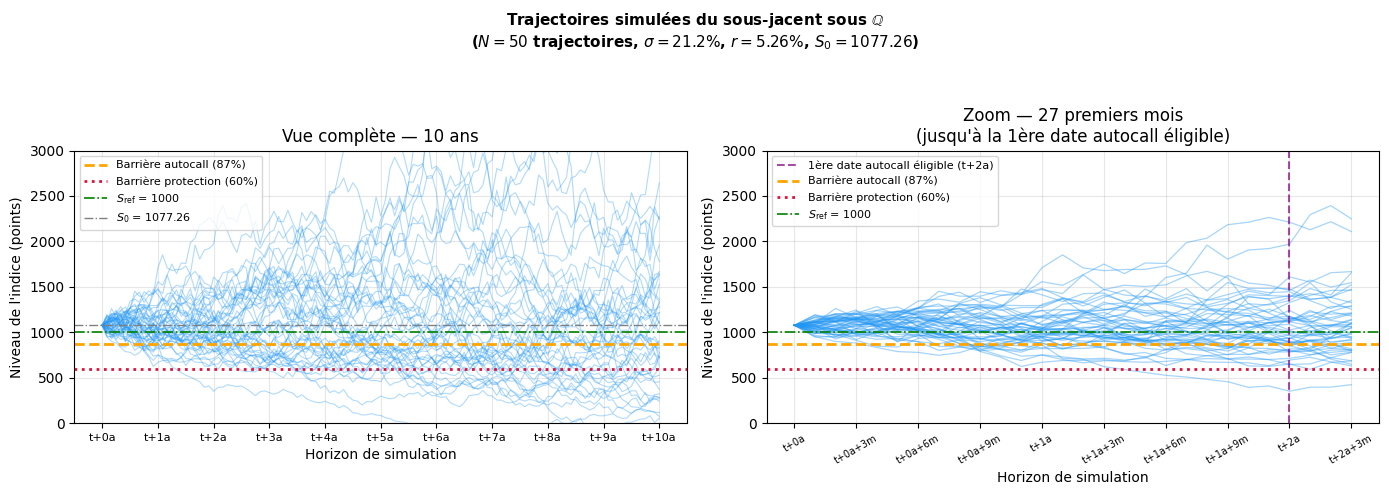

✓ Figure sauvegardée : trajectoires_simulees.png


In [0]:
import numpy as np
import matplotlib.pyplot as plt

# ── Paramètres (déjà définis dans le notebook) ──────────────────
N_TRAJ_PLOT  = 50
T_PLOT_MONTHS = ANNEE_FINALE * 12   # 120 mois
YLIM_MAX     = 3000                  # cap truc y

paths_plot = simulate_gbm_monthly(
    s0           = S0_T0,
    r_annual_cc  = R_NEUTRE_CC,
    sigma_annual = SIGMA_ANNUAL,
    start_date   = str(DATE_VAL_T0.date()),
    n_months     = T_PLOT_MONTHS,
    n_sims       = N_TRAJ_PLOT,
    seed         = 999,
)
paths_plot_dec = decrement_paths(
    paths_plot,
    decrement_value  = DECREMENT_VAL,
    periods_per_year = 12,
    mode             = DECREMENT_MODE,
    offset_periods   = 0,
)

vals = paths_plot_dec.values  # shape (N_TRAJ_PLOT, T_PLOT_MONTHS+1)

# Couleur par comportement final (autocall ou non)
# Une trajectoire "autocall early" = franchit barriere avant t+24mois
B_AC  = BARRIERE_AUTOCALL * S_REF
B_PR  = BARRIERE_PROTECTION * S_REF

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel gauche : 10 ans complets ──────────────────────────────
ax = axes[0]
xticks_full = list(range(0, T_PLOT_MONTHS + 1, 12))

for i in range(N_TRAJ_PLOT):
    traj = vals[i]
    # Couleur selon issue finale
    if np.any(traj[:25] >= B_AC):          # autocall dans les 2 premières années
        col, alpha = "#2196F3", 0.35       # bleu
    elif traj[-1] < B_PR:                  # finit sous protection
        col, alpha = "#E53935", 0.50       # rouge
    else:
        col, alpha = "#90CAF9", 0.25       # bleu pale

    ax.plot(range(T_PLOT_MONTHS + 1), traj,
            color=col, alpha=alpha, lw=0.8)

# Barrières
ax.axhline(B_AC, color="orange",  lw=2,   ls="--",
           label=f"Barrière autocall ({BARRIERE_AUTOCALL*100:.0f}%)")
ax.axhline(B_PR, color="crimson", lw=2,   ls=":",
           label=f"Barrière protection ({BARRIERE_PROTECTION*100:.0f}%)")
ax.axhline(S_REF, color="green",  lw=1.2, ls="-.",
           label=f"$S_{{\\mathrm{{ref}}}}$ = {S_REF:.0f}")
ax.axhline(S0_T0, color="gray",   lw=1,   ls="-.",
           label=f"$S_0$ = {S0_T0:.2f}")

ax.set_ylim(0, YLIM_MAX)
ax.set_xticks(xticks_full)
ax.set_xticklabels([f"t+{k//12}a" for k in xticks_full], fontsize=8)
ax.set_xlabel("Horizon de simulation")
ax.set_ylabel("Niveau de l'indice (points)")
ax.set_title("Vue complète — 10 ans")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

# ── Panel droit : zoom 2 premières années ───────────────────────
ax2 = axes[1]
T_ZOOM = 27      # 27 mois = un peu après la 1ère date autocall (mois 24)
xticks_zoom = list(range(0, T_ZOOM + 1, 3))

for i in range(N_TRAJ_PLOT):
    traj_zoom = vals[i, :T_ZOOM + 1]
    if np.any(traj_zoom >= B_AC):
        col, alpha = "#2196F3", 0.40
    elif vals[i, -1] < B_PR:
        col, alpha = "#E53935", 0.50
    else:
        col, alpha = "#90CAF9", 0.30

    ax2.plot(range(T_ZOOM + 1), traj_zoom,
             color=col, alpha=alpha, lw=0.9)

# Marquer la première date éligible autocall (mois 24 = trimestre 8)
ax2.axvline(24, color="purple", lw=1.5, ls="--", alpha=0.7,
            label="1ère date autocall éligible (t+2a)")
ax2.axhline(B_AC, color="orange",  lw=2,   ls="--",
            label=f"Barrière autocall ({BARRIERE_AUTOCALL*100:.0f}%)")
ax2.axhline(B_PR, color="crimson", lw=2,   ls=":",
            label=f"Barrière protection ({BARRIERE_PROTECTION*100:.0f}%)")
ax2.axhline(S_REF, color="green",  lw=1.2, ls="-.",
            label=f"$S_{{\\mathrm{{ref}}}}$ = {S_REF:.0f}")

ax2.set_ylim(0, YLIM_MAX)
ax2.set_xticks(xticks_zoom)
ax2.set_xticklabels(
    [f"t+{k//12}a{'+'+str(k%12)+'m' if k%12 else ''}" for k in xticks_zoom],
    fontsize=7, rotation=30
)
ax2.set_xlabel("Horizon de simulation")
ax2.set_ylabel("Niveau de l'indice (points)")
ax2.set_title("Zoom — 27 premiers mois\n(jusqu'à la 1ère date autocall éligible)")
ax2.legend(fontsize=8, loc="upper left")
ax2.grid(True, alpha=0.3)

# ── Titre global ─────────────────────────────────────────────────
fig.suptitle(
    f"Trajectoires simulées du sous-jacent sous $\\mathbb{{Q}}$\n"
    f"($N = {N_TRAJ_PLOT}$ trajectoires, $\\sigma = {SIGMA_ANNUAL*100:.1f}\\%$, "
    f"$r = {R_NEUTRE_CC*100:.2f}\\%$, $S_0 = {S0_T0:.2f}$)",
    fontsize=11, fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("trajectoires_simulees.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : trajectoires_simulees.png")

---
## Section 6 — Analyse de sensibilité de VM₀ au niveau initial S₀

Objectif : illustrer numériquement la non-linéarité du Support à Formule et
quantifier l'écart avec l'approximation actions (variation proportionnelle),
en recalculant VM₀ pour une grille de valeurs de S₀.

## 6. Analyse de sensibilité de VM₀

Réorganisation (voir plan Notion « Chap 2 – Black-Scholes, VM₀ ») : chaque facteur de risque (S₀, σ) regroupe désormais **VM₀(x) + impact sur la distribution des sorties anticipées** dans une même sous-section, au lieu de séparer ces deux analyses.

### 6.1 — Sensibilité au niveau initial du sous-jacent S₀

*(Courbe fine, Delta, élasticité : code existant inchangé ci-dessous.)*

In [0]:
# ═══════════════════════════════════════════════════════════════════════
# ANALYSE DE SENSIBILITÉ — VM₀ en fonction de S₀
# Objectif : illustrer la non-linéarité du Support à Formule
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Grid de valeurs S0 à tester ────────────────────────────────────
s0_min = 0.40 * S_REF   # 40% de S_ref = 400 pts
s0_max = 1.60 * S_REF   # 160% de S_ref = 1600 pts
n_grid = 60             # nombre de points (assez dense pour la courbe)

s0_grid   = np.linspace(s0_min, s0_max, n_grid)
vm0_grid  = np.zeros(n_grid)

N_SIMS_SENSI = 5000     # moins de sims que VM0 principal pour aller vite

# ── 2. Calcul VM₀ pour chaque S0 ──────────────────────────────────────
n_months = _months_to_reach(DATE_VAL_T0,
                             pd.Timestamp(DATE_DEBUT) + pd.DateOffset(years=ANNEE_FINALE))

for idx, s0_val in enumerate(s0_grid):
    # Simulation trajectoires sous Q
    paths_sensi = simulate_gbm_monthly(
        s0          = s0_val,
        r_annual_cc = R_NEUTRE_CC,
        sigma_annual= SIGMA_ANNUAL,
        start_date  = DATE_VAL_T0,
        n_months    = n_months,
        n_sims      = N_SIMS_SENSI,
        seed        = 42,
    )

    # Décrément
    paths_dec = decrement_paths(
        paths_sensi,
        decrement_value  = DECREMENT_VAL,
        periods_per_year = 12,
        mode             = DECREMENT_MODE,
        offset_periods   = int(round(
            (DATE_VAL_T0 - pd.Timestamp(DATE_DEBUT)).days / 30.44
        )),
    )

    # Payoff
    pf = Payoff(
        paths                   = paths_dec,
        date_debut              = DATE_DEBUT,
        s_ref                   = S_REF,
        barriere_sortie_anticipe= BARRIERE_AUTOCALL,
        barriere_sortie_maturite= BARRIERE_FINAL,
        barriere_protection     = BARRIERE_PROTECTION,
        premiere_annee_sortie   = PREMIERE_ANNEE_SORTIE,
        freq_sortie             = FREQ_SORTIE,
        coupon_par_periode      = COUPON_PAR_PERIODE,
        annee_finale            = ANNEE_FINALE,
    )

    # VM₀

    _, vm0_grid[idx] = VM(pf, taux_df,
                          date_valuation=DATE_VAL_T0,
                          compounding=COMPOUNDING,
                          day_count=DAY_COUNT)

print("✓ Sensitivity analysis terminée")
print(f"   S0 range : [{s0_grid[0]:.0f}, {s0_grid[-1]:.0f}]")
print(f"   VM0 range: [{vm0_grid.min():.2f}, {vm0_grid.max():.2f}]")

✓ Sensitivity analysis terminée
   S0 range : [400, 1600]
   VM0 range: [222.13, 1108.95]


In [0]:
# ── 3. Delta par différences finies centrées ───────────────────────────
delta_val  = np.diff(vm0_grid) / np.diff(s0_grid)        # shape: (n_grid-1,)
delta_centered = (delta_val[:-1] + delta_val[1:]) / 2.0  # shape: (n_grid-2,)
delta_s0   = s0_grid[1:-1]                                # shape: (n_grid-2,) ✓

print(f"✓ Delta calculé — shape check: s0={delta_s0.shape}, delta={delta_centered.shape}")
print(f"   Delta min : {delta_centered.min():.4f}")
print(f"   Delta max : {delta_centered.max():.4f}")

✓ Delta calculé — shape check: s0=(58,), delta=(58,)
   Delta min : 0.0070
   Delta max : 1.8225


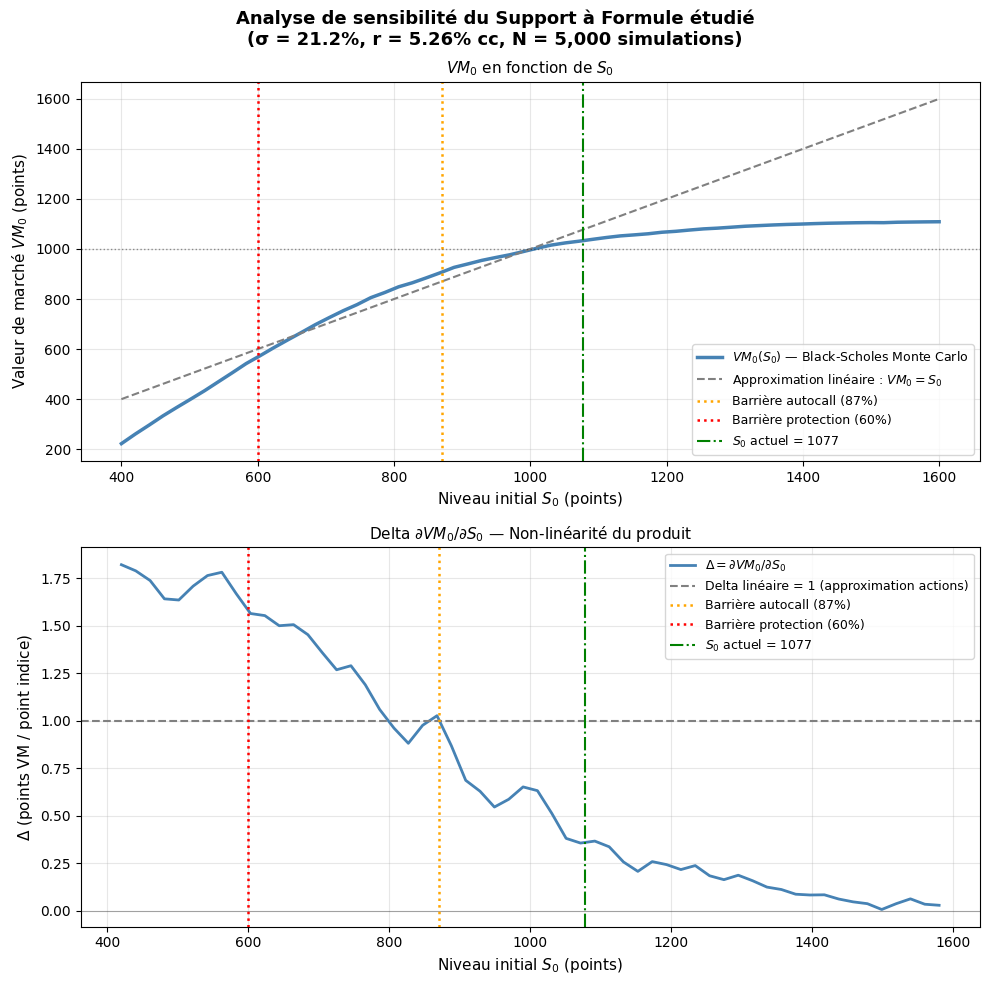

In [0]:
# ── 4. Figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle("Analyse de sensibilité du Support à Formule étudié\n"
             f"(σ = {SIGMA_ANNUAL:.1%}, r = {R_NEUTRE_CC:.2%} cc, "
             f"N = {N_SIMS_SENSI:,} simulations)",
             fontsize=13, fontweight='bold')

# Panel 1 — VM₀ vs S₀
ax1 = axes[0]
ax1.plot(s0_grid, vm0_grid, color='steelblue', linewidth=2.5,
         label=r'$VM_0(S_0)$ — Black-Scholes Monte Carlo')
ax1.plot(s0_grid, s0_grid, color='gray', linewidth=1.5,
         linestyle='--', label=r'Approximation linéaire : $VM_0 = S_0$')
ax1.axvline(x=BARRIERE_AUTOCALL * S_REF, color='orange', linestyle=':',
            linewidth=1.8, label=f'Barrière autocall ({BARRIERE_AUTOCALL:.0%})')
ax1.axvline(x=BARRIERE_PROTECTION * S_REF, color='red', linestyle=':',
            linewidth=1.8, label=f'Barrière protection ({BARRIERE_PROTECTION:.0%})')
ax1.axvline(x=S0_T0, color='green', linestyle='-.',
            linewidth=1.5, label=f'$S_0$ actuel = {S0_T0:.0f}')
ax1.axhline(y=S_REF, color='black', linestyle=':', linewidth=1.0, alpha=0.4)
ax1.set_xlabel(r'Niveau initial $S_0$ (points)', fontsize=11)
ax1.set_ylabel(r'Valeur de marché $VM_0$ (points)', fontsize=11)
ax1.set_title(r'$VM_0$ en fonction de $S_0$', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2 — Delta ← CORRIGÉ
ax2 = axes[1]
ax2.plot(delta_s0, delta_centered,          # ← delta_s0 SANS [:-1]
         color='steelblue', linewidth=2.0,
         label=r'$\Delta = \partial VM_0 / \partial S_0$')
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5,
            label='Delta linéaire = 1 (approximation actions)')
ax2.axhline(y=0.0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax2.axvline(x=BARRIERE_AUTOCALL * S_REF, color='orange', linestyle=':',
            linewidth=1.8, label=f'Barrière autocall ({BARRIERE_AUTOCALL:.0%})')
ax2.axvline(x=BARRIERE_PROTECTION * S_REF, color='red', linestyle=':',
            linewidth=1.8, label=f'Barrière protection ({BARRIERE_PROTECTION:.0%})')
ax2.axvline(x=S0_T0, color='green', linestyle='-.',
            linewidth=1.5, label=f'$S_0$ actuel = {S0_T0:.0f}')
ax2.set_xlabel(r'Niveau initial $S_0$ (points)', fontsize=11)
ax2.set_ylabel(r'$\Delta$ (points VM / point indice)', fontsize=11)
ax2.set_title(r'Delta $\partial VM_0 / \partial S_0$ — Non-linéarité du produit',
              fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("image_p/sensitivity_vm0_vs_s0.png", dpi=150, bbox_inches='tight')
plt.show()

In [0]:
# ── 5. Tableau synthèse des écarts linéaire vs réel ────────────────────
# Quelques points clés pour le mémoire

key_levels = {
    f"{BARRIERE_PROTECTION*100:.0f}% S_ref (barrière prot.)":  BARRIERE_PROTECTION * S_REF,
    "80% S_ref":                                                0.80 * S_REF,
    f"{BARRIERE_AUTOCALL*100:.0f}% S_ref (barrière autocall)":  BARRIERE_AUTOCALL * S_REF,
    "100% S_ref":                                               1.00 * S_REF,
    f"S0 actuel ({S0_T0:.0f})":                                 S0_T0,
    "120% S_ref":                                               1.20 * S_REF,
    "140% S_ref":                                               1.40 * S_REF,
}

print(f"{'Niveau S0':35s} {'S0':>8} {'VM0 BS':>10} "
      f"{'Approx lin.':>12} {'Écart':>10} {'Écart %':>9}")
print("-" * 90)

for label, s0_val in key_levels.items():
    # Interpolation linéaire dans vm0_grid
    vm0_interp = np.interp(s0_val, s0_grid, vm0_grid)
    ecart      = vm0_interp - s0_val
    ecart_pct  = ecart / s0_val * 100
    print(f"{label:35s} {s0_val:8.1f} {vm0_interp:10.2f} "
          f"{s0_val:12.2f} {ecart:+10.2f} {ecart_pct:+8.2f}%")

Niveau S0                                 S0     VM0 BS  Approx lin.      Écart   Écart %
------------------------------------------------------------------------------------------
60% S_ref (barrière prot.)             600.0     568.14       600.00     -31.86    -5.31%
80% S_ref                              800.0     841.24       800.00     +41.24    +5.16%
87% S_ref (barrière autocall)          870.0     907.27       870.00     +37.27    +4.28%
100% S_ref                            1000.0     996.51      1000.00      -3.49    -0.35%
S0 actuel (1077)                      1077.3    1033.31      1077.26     -43.95    -4.08%
120% S_ref                            1200.0    1068.21      1200.00    -131.79   -10.98%
140% S_ref                            1400.0    1099.88      1400.00    -300.12   -21.44%


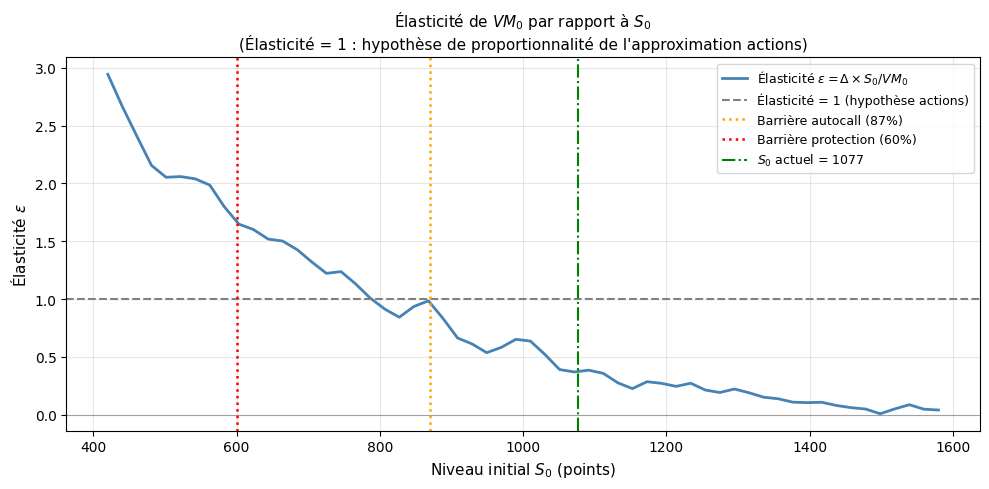


Niveau S0                                 S0      VM0    Delta   Elasticité   Biais approx.
------------------------------------------------------------------------------------------
60% S_ref (barrière prot.)               600    568.1    1.583        1.672         +67.2%
80% S_ref                                800    841.2    0.995        0.946          -5.4%
87% S_ref (barrière autocall)            870    907.3    1.010        0.969          -3.1%
100% S_ref                              1000    996.5    0.643        0.645         -35.5%
S0 actuel (1077)                        1077   1033.3    0.360        0.375         -62.5%
120% S_ref                              1200   1068.2    0.235        0.264         -73.6%
140% S_ref                              1400   1099.9    0.083        0.106         -89.4%


In [0]:
# ── Elasticité VM par rapport à S ─────────────────────────────────────
# ε(S0) = Delta × (S0 / VM0) = (∂VM/∂S) × (S/VM)

# Interpoler VM0 sur les points où Delta est disponible
vm0_at_delta = np.interp(delta_s0, s0_grid, vm0_grid)

# Elasticité
elasticite = delta_centered * (delta_s0 / vm0_at_delta)

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(delta_s0, elasticite, color='steelblue', linewidth=2.0,
        label=r'Élasticité $\varepsilon = \Delta \times S_0 / VM_0$')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5,
           label='Élasticité = 1 (hypothèse actions)')
ax.axhline(y=0.0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

ax.axvline(x=BARRIERE_AUTOCALL * S_REF, color='orange', linestyle=':',
           linewidth=1.8, label=f'Barrière autocall ({BARRIERE_AUTOCALL:.0%})')
ax.axvline(x=BARRIERE_PROTECTION * S_REF, color='red', linestyle=':',
           linewidth=1.8, label=f'Barrière protection ({BARRIERE_PROTECTION:.0%})')
ax.axvline(x=S0_T0, color='green', linestyle='-.',
           linewidth=1.5, label=f'$S_0$ actuel = {S0_T0:.0f}')

ax.set_xlabel(r'Niveau initial $S_0$ (points)', fontsize=11)
ax.set_ylabel(r'Élasticité $\varepsilon$', fontsize=11)
ax.set_title(r'Élasticité de $VM_0$ par rapport à $S_0$'
             "\n(Élasticité = 1 : hypothèse de proportionnalité de l'approximation actions)",
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("image_p/elasticite_vm0.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Tableau aux points clés ────────────────────────────────────────────
print(f"\n{'Niveau S0':35s} {'S0':>8} {'VM0':>8} {'Delta':>8} {'Elasticité':>12} {'Biais approx.':>15}")
print("-" * 90)

for label, s0_val in key_levels.items():
    vm0_i  = np.interp(s0_val, s0_grid, vm0_grid)
    delta_i = np.interp(s0_val, delta_s0, delta_centered)
    elast_i = delta_i * s0_val / vm0_i
    biais   = (elast_i - 1.0) * 100
    print(f"{label:35s} {s0_val:8.0f} {vm0_i:8.1f} "
          f"{delta_i:8.3f} {elast_i:12.3f} {biais:+13.1f}%")

In [0]:
# ═══════════════════════════════════════════════════════════════════════
# HELPERS — métriques de distribution des sorties (réutilisés pour S0 et σ)
# ═══════════════════════════════════════════════════════════════════════

def get_first_window_date(date_val_t0, n_months, date_debut, premiere_annee_sortie):
    """
    Date (mappée sur la grille mensuelle) de la 1ère fenêtre d'observation autocall.
    Ne dépend ni de S0 ni de σ (seulement de T via n_months), donc calculée UNE FOIS
    et réutilisée pour toutes les grilles de sensibilité S0 et σ.
    """
    grid = pd.date_range(start=str(pd.Timestamp(date_val_t0).date()),
                          periods=n_months + 1, freq="ME")
    first_obs_theo = pd.Timestamp(date_debut) + pd.DateOffset(years=premiere_annee_sortie)
    pos = grid.searchsorted(first_obs_theo, side="left")
    return grid[pos]


def distribution_metrics(pay_tbl, vm_tbl, first_window_date):
    """
    3 indicateurs résumant la distribution des dates de sortie, sans avoir à
    afficher la distribution complète à chaque point de la grille de sensibilité :
      - P(sortie à la 1ère fenêtre éligible)
      - E[T_sortie]  (durée de vie effective moyenne, en années)
      - P(maturité)  (probabilité de ne jamais être autocallé)
    """
    p_sortie_f1  = float((pay_tbl["Date_sortie"] == first_window_date).mean())
    p_maturite   = float((~pay_tbl["Called"]).mean())
    e_t_sortie   = float(vm_tbl["T_en_annees"].mean())
    return {
        "P(sortie an.1) %":   round(p_sortie_f1 * 100, 2),
        "E[T_sortie] (ans)":  round(e_t_sortie, 3),
        "P(maturité) %":      round(p_maturite * 100, 2),
    }


# Date de la 1ère fenêtre — calculée une fois, réutilisée dans 6.1 et 6.2
n_months_sens = _months_to_reach(DATE_VAL_T0, DATE_DEBUT + pd.DateOffset(years=ANNEE_FINALE))
FIRST_WINDOW_DATE = get_first_window_date(DATE_VAL_T0, n_months_sens, DATE_DEBUT, PREMIERE_ANNEE_SORTIE)
print(f"✓ 1ère fenêtre d'observation autocall (grille mensuelle) : {FIRST_WINDOW_DATE.date()}")

✓ 1ère fenêtre d'observation autocall (grille mensuelle) : 2027-08-31


#### Tableau discret — VM₀(S0) + distribution des sorties

Même grille de chocs que `tab:sensibilite_vm0` (±5/10/20 %), avec en plus les 3 indicateurs de distribution calculés à partir de la même table `pay_tbl` (aucune simulation supplémentaire).

In [0]:
chocs = [-0.20, -0.10, -0.05, 0.00, 0.05, 0.10, 0.20, 0.39]
n_months = n_months_sens  # défini dans la cellule helper ci-dessus

resultats_sensi = []
vm0_base = None

for x in chocs:
    s0_choc = S0_T0 * (1 + x)

    paths = simulate_gbm_monthly(
        s0=s0_choc, r_annual_cc=R_NEUTRE_CC, sigma_annual=SIGMA_ANNUAL,
        start_date=str(DATE_VAL_T0.date()), n_months=n_months,
        n_sims=10_000, seed=0,
    )
    paths_dec = decrement_paths(paths, decrement_value=DECREMENT_VAL,
                                 periods_per_year=12, mode=DECREMENT_MODE, offset_periods=0)
    pay_tbl = Payoff(
        paths=paths_dec, date_debut=DATE_DEBUT, s_ref=S_REF,
        barriere_sortie_anticipe=BARRIERE_AUTOCALL, barriere_sortie_maturite=BARRIERE_FINAL,
        barriere_protection=BARRIERE_PROTECTION, premiere_annee_sortie=PREMIERE_ANNEE_SORTIE,
        freq_sortie=FREQ_SORTIE, coupon_par_periode=COUPON_PAR_PERIODE,
        annee_finale=ANNEE_FINALE, day_count=DAY_COUNT,
    )
    vm_tbl, vm0_x = VM(payoff_table=pay_tbl, courbe_taux=taux_df, date_valuation=DATE_VAL_T0,
                        compounding=COMPOUNDING, day_count=DAY_COUNT)

    if x == 0.00:
        vm0_base = vm0_x

    # --- construction + append : DOIT être dans la boucle, une ligne par choc ---
    row = {"Choc (%)": x * 100, "VM0 modèle": vm0_x}
    row.update(distribution_metrics(pay_tbl, vm_tbl, FIRST_WINDOW_DATE))
    resultats_sensi.append(row)

df_sensi = pd.DataFrame(resultats_sensi)
df_sensi["VM0 actions"] = vm0_base * (1 + df_sensi["Choc (%)"] / 100)
df_sensi["Écart (%)"] = (df_sensi["VM0 modèle"] - df_sensi["VM0 actions"]) / df_sensi["VM0 actions"] * 100

df_sensi = df_sensi[["Choc (%)", "VM0 modèle", "VM0 actions", "Écart (%)",
                      "P(sortie an.1) %", "E[T_sortie] (ans)", "P(maturité) %"]]

print(df_sensi.round(2).to_string(index=False))
print()
print(df_sensi.round(2).to_latex(index=False, float_format="%.2f"))

 Choc (%)  VM0 modèle  VM0 actions  Écart (%)  P(sortie an.1) %  E[T_sortie] (ans)  P(maturité) %
    -20.0      927.59       838.68      10.60             43.07               4.32          23.81
    -10.0      998.71       943.51       5.85             59.62               3.40          15.17
     -5.0     1027.14       995.93       3.13             66.69               3.01          11.65
      0.0     1048.35      1048.35       0.00             73.46               2.71           8.88
      5.0     1064.09      1100.76      -3.33             79.30               2.47           6.78
     10.0     1077.56      1153.18      -6.56             83.84               2.27           5.09
     20.0     1094.14      1258.02     -13.03             90.40               2.01           2.76
     39.0     1106.07      1457.20     -24.10             96.41               1.77           0.85

\begin{tabular}{rrrrrrr}
\toprule
Choc (%) & VM0 modèle & VM0 actions & Écart (%) & P(sortie an.1) % & E[T_sortie] (a

### 6.2 — Sensibilité de VM₀ à la volatilité σ

**Benchmark** : l'approximation actions ne fait intervenir aucune volatilité — cela équivaut à un Vega implicite nul (Vega ≡ 0). Le benchmark naïf est donc une **droite plate** $\mathrm{VM}_0^{\text{naïf}}(\sigma) = \mathrm{VM}_0(\sigma_{\text{ref}})$, et non une droite proportionnelle comme pour S₀.

**Grille** : chocs en **points de volatilité absolus** (±3/5/10 pts autour de σ_ref = 21,20 %), convention standard en risk management — pas de choc relatif en %, contrairement à S₀.

In [0]:
# ═══════════════════════════════════════════════════════════════════════
# SENSIBILITÉ DE VM0 À LA VOLATILITÉ σ — chocs discrets ±3/5/10 points de vol
# Benchmark naïf : VM0 constant (Vega ≡ 0 implicite de l'approximation actions)
# ═══════════════════════════════════════════════════════════════════════

sigma_chocs_pts = [-0.10, -0.05, -0.03, 0.00, 0.03, 0.05, 0.10]   # points de vol absolus
n_months = n_months_sens   # inchangé par σ (contrairement à S0, cf. note Notion)

resultats_sensi_vol = []
vm0_base_vol = None

for dx in sigma_chocs_pts:
    sigma_choc = SIGMA_ANNUAL + dx

    paths = simulate_gbm_monthly(
        s0=S0_T0, r_annual_cc=R_NEUTRE_CC, sigma_annual=sigma_choc,
        start_date=str(DATE_VAL_T0.date()), n_months=n_months,
        n_sims=10_000, seed=0,                      # même seed pour chaque choc
    )
    paths_dec = decrement_paths(paths, decrement_value=DECREMENT_VAL,
                                 periods_per_year=12, mode=DECREMENT_MODE, offset_periods=0)
    pay_tbl = Payoff(
        paths=paths_dec, date_debut=DATE_DEBUT, s_ref=S_REF,
        barriere_sortie_anticipe=BARRIERE_AUTOCALL, barriere_sortie_maturite=BARRIERE_FINAL,
        barriere_protection=BARRIERE_PROTECTION, premiere_annee_sortie=PREMIERE_ANNEE_SORTIE,
        freq_sortie=FREQ_SORTIE, coupon_par_periode=COUPON_PAR_PERIODE,
        annee_finale=ANNEE_FINALE, day_count=DAY_COUNT,
    )
    vm_tbl, vm0_x = VM(payoff_table=pay_tbl, courbe_taux=taux_df, date_valuation=DATE_VAL_T0,
                        compounding=COMPOUNDING, day_count=DAY_COUNT)

    if dx == 0.00:
        vm0_base_vol = vm0_x

    row = {"Choc vol (pts)": dx * 100, "sigma (%)": sigma_choc * 100, "VM0 modèle": vm0_x}
    row.update(distribution_metrics(pay_tbl, vm_tbl, FIRST_WINDOW_DATE))
    resultats_sensi_vol.append(row)

df_sensi_vol = pd.DataFrame(resultats_sensi_vol)
df_sensi_vol["VM0 benchmark (Vega=0)"] = vm0_base_vol
df_sensi_vol["Écart (%)"] = (df_sensi_vol["VM0 modèle"] - vm0_base_vol) / vm0_base_vol * 100

df_sensi_vol = df_sensi_vol[["Choc vol (pts)", "sigma (%)", "VM0 modèle",
                              "VM0 benchmark (Vega=0)", "Écart (%)",
                              "P(sortie an.1) %", "E[T_sortie] (ans)", "P(maturité) %"]]

print(df_sensi_vol.round(3).to_string(index=False))
print()
print(df_sensi_vol.round(2).to_latex(index=False, float_format="%.2f"))

# ── Vega par différences finies centrées (h = 3 points de vol) ─────────────
vm0_plus3  = df_sensi_vol.loc[df_sensi_vol["Choc vol (pts)"].round(2) ==  3.0, "VM0 modèle"].values[0]
vm0_minus3 = df_sensi_vol.loc[df_sensi_vol["Choc vol (pts)"].round(2) == -3.0, "VM0 modèle"].values[0]
h_points = 3.0   # en POINTS de vol (pas en décimal) — cf. convention du choc ±3 pts ci-dessus
vega = (vm0_plus3 - vm0_minus3) / (2 * h_points)   # points de VM par POINT de volatilité (0,01 de sigma)

print()
print(f"✓ Vega ≈ {vega:.2f} points de VM par point de volatilité (Δσ = 1 pt = 0,01)")
print(f"   soit {vega / vm0_base_vol * 100:.3f} % de VM0 pour un choc de +1 point de vol")
print(f"   (méthode : différence centrée, h = ±3 pts — cf. Korn, Korn & Kroisandt §5.15.6)")

 Choc vol (pts)  sigma (%)  VM0 modèle  VM0 benchmark (Vega=0)  Écart (%)  P(sortie an.1) %  E[T_sortie] (ans)  P(maturité) %
          -10.0       11.2    1108.249                1048.346      5.714             91.69              1.931           1.90
           -5.0       16.2    1085.006                1048.346      3.497             81.73              2.338           5.38
           -3.0       18.2    1069.560                1048.346      2.024             78.29              2.498           6.88
            0.0       21.2    1048.346                1048.346      0.000             73.46              2.710           8.88
            3.0       24.2    1024.384                1048.346     -2.286             69.29              2.910          10.90
            5.0       26.2    1007.614                1048.346     -3.885             66.93              3.039          12.17
           10.0       31.2     962.073                1048.346     -8.229             62.29              3.332        

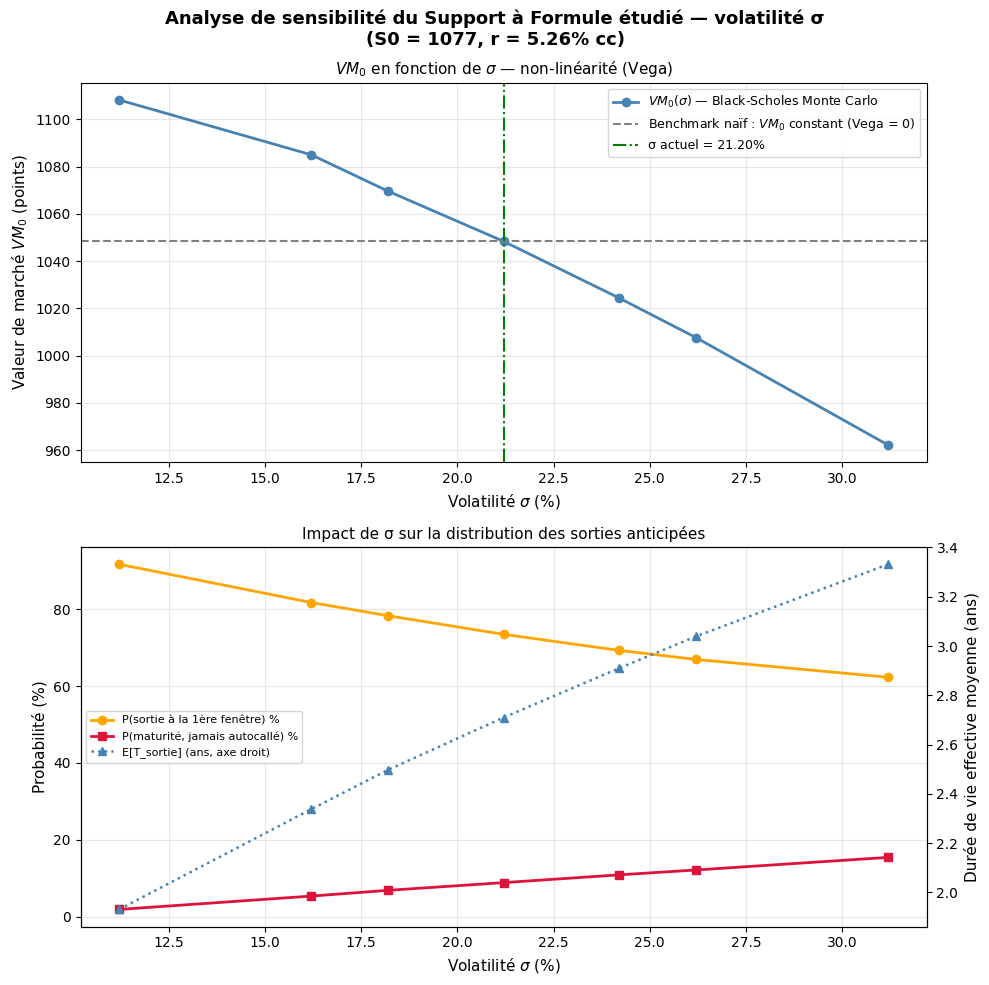

In [0]:
# ── Figure — VM0(σ) vs benchmark Vega=0, + distribution des sorties vs σ ───
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle("Analyse de sensibilité du Support à Formule étudié — volatilité σ\n"
             f"(S0 = {S0_T0:.0f}, r = {R_NEUTRE_CC:.2%} cc)",
             fontsize=13, fontweight='bold')

# Panel 1 — VM0 vs sigma
ax1 = axes[0]
ax1.plot(df_sensi_vol["sigma (%)"], df_sensi_vol["VM0 modèle"], color='steelblue',
         marker='o', linewidth=2.0, label=r'$VM_0(\sigma)$ — Black-Scholes Monte Carlo')
ax1.axhline(y=vm0_base_vol, color='gray', linestyle='--', linewidth=1.5,
            label=r'Benchmark naïf : $VM_0$ constant (Vega = 0)')
ax1.axvline(x=SIGMA_ANNUAL * 100, color='green', linestyle='-.', linewidth=1.5,
            label=f'σ actuel = {SIGMA_ANNUAL:.2%}')
ax1.set_xlabel(r'Volatilité $\sigma$ (%)', fontsize=11)
ax1.set_ylabel(r'Valeur de marché $VM_0$ (points)', fontsize=11)
ax1.set_title(r'$VM_0$ en fonction de $\sigma$ — non-linéarité (Vega)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2 — distribution des sorties vs sigma
ax2 = axes[1]
ax2.plot(df_sensi_vol["sigma (%)"], df_sensi_vol["P(sortie an.1) %"], color='orange',
         marker='o', linewidth=2.0, label='P(sortie à la 1ère fenêtre) %')
ax2.plot(df_sensi_vol["sigma (%)"], df_sensi_vol["P(maturité) %"], color='crimson',
         marker='s', linewidth=2.0, label='P(maturité, jamais autocallé) %')
ax2.set_xlabel(r'Volatilité $\sigma$ (%)', fontsize=11)
ax2.set_ylabel('Probabilité (%)', fontsize=11)
ax2b = ax2.twinx()
ax2b.plot(df_sensi_vol["sigma (%)"], df_sensi_vol["E[T_sortie] (ans)"], color='steelblue',
          marker='^', linewidth=1.8, linestyle=':', label='E[T_sortie] (ans, axe droit)')
ax2b.set_ylabel('Durée de vie effective moyenne (ans)', fontsize=11)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center left')
ax2.set_title("Impact de σ sur la distribution des sorties anticipées", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("image_p/sensitivity_vm0_vs_sigma.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7 — Figure pédagogique : structure du payoff à maturité

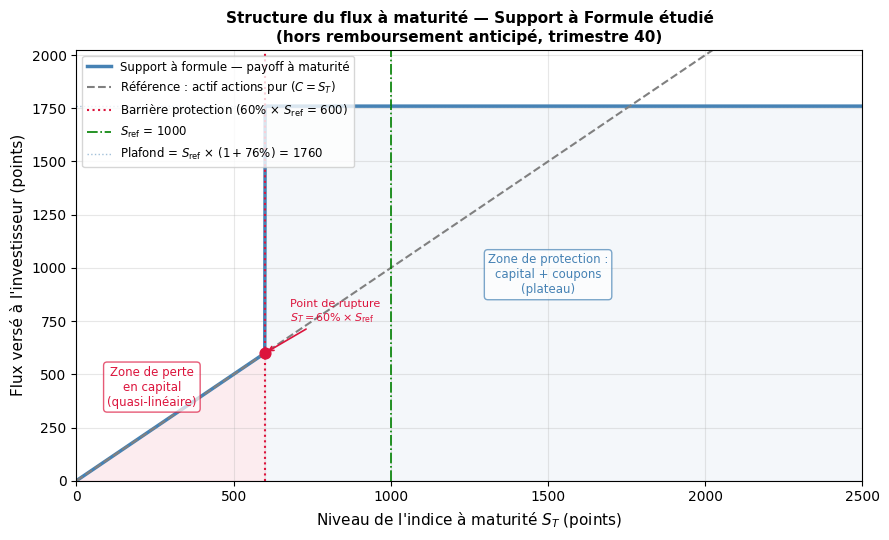

✓ Figure sauvegardée : payoff_structure.png
  Barrière protection : 600 pts
  Plafond (capital + coupons max) : 1760 pts


In [0]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Paramètres (déjà définis dans le notebook) ──────────────────
# S_REF, BARRIERE_AUTOCALL, BARRIERE_PROTECTION, COUPON_PAR_PERIODE
# ANNEE_FINALE (= 10 ans = 40 trimestres)

N_TRIMESTRES = ANNEE_FINALE * 4   # 40 trimestres
COUPON_MAX   = COUPON_PAR_PERIODE * N_TRIMESTRES  # calculé dynamiquement à partir du produit sélectionné

# ── Grille de valeurs ST ────────────────────────────────────────
ST = np.linspace(0, 2.5 * S_REF, 2000)

# ── Payoff à maturité (trimestre 40, pas d'autocall déclenché) ──
payoff_saf = np.where(
    ST >= BARRIERE_PROTECTION * S_REF,
    S_REF * (1 + COUPON_MAX),   # capital + coupons max
    ST                           # perte en capital proportionnelle
)

# Référence : actif actions pur (relation linéaire)
payoff_action = ST

# ── Figure ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

# Courbes
ax.plot(ST, payoff_saf,
        color="steelblue", lw=2.5,
        label=f"Support à formule — payoff à maturité")
ax.plot(ST, payoff_action,
        color="gray", lw=1.5, ls="--",
        label="Référence : actif actions pur ($C = S_T$)")

# Lignes verticales des barrières
ax.axvline(BARRIERE_PROTECTION * S_REF,
           color="crimson", lw=1.5, ls=":",
           label=f"Barrière protection "
                 f"({BARRIERE_PROTECTION*100:.0f}% × $S_{{\\mathrm{{ref}}}}$"
                 f" = {BARRIERE_PROTECTION*S_REF:.0f})")
ax.axvline(S_REF,
           color="green", lw=1.2, ls="-.",
           label=f"$S_{{\\mathrm{{ref}}}}$ = {S_REF:.0f}")

# Ligne horizontale du plateau
ax.axhline(S_REF * (1 + COUPON_MAX),
           color="steelblue", lw=1, ls=":",
           alpha=0.5,
           label=f"Plafond = $S_{{\\mathrm{{ref}}}}$ × "
                 f"$(1 + {COUPON_MAX*100:.0f}\\%)$"
                 f" = {S_REF*(1+COUPON_MAX):.0f}")

# Zones colorées
ax.fill_between(ST, 0, payoff_saf,
                where=(ST < BARRIERE_PROTECTION * S_REF),
                alpha=0.08, color="crimson",
                label="_nolegend_")
ax.fill_between(ST, 0, payoff_saf,
                where=(ST >= BARRIERE_PROTECTION * S_REF),
                alpha=0.06, color="steelblue",
                label="_nolegend_")

# Annotations des zones
ax.text(BARRIERE_PROTECTION * S_REF * 0.40,
        S_REF * (1 + COUPON_MAX) * 0.25,
        "Zone de perte\nen capital\n(quasi-linéaire)",
        fontsize=8.5, color="crimson", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  ec="crimson", alpha=0.7))

ax.text(S_REF * 1.50,
        S_REF * (1 + COUPON_MAX) * 0.55,
        "Zone de protection :\ncapital + coupons\n(plateau)",
        fontsize=8.5, color="steelblue", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  ec="steelblue", alpha=0.7))

# Point de rupture (60% × S_ref)
ax.scatter([BARRIERE_PROTECTION * S_REF],
           [BARRIERE_PROTECTION * S_REF],
           color="crimson", zorder=5, s=60)
ax.annotate(
    f"Point de rupture\n"
    f"$S_T = {BARRIERE_PROTECTION*100:.0f}\\%"
    f" \\times S_{{\\mathrm{{ref}}}}$",
    xy=(BARRIERE_PROTECTION * S_REF,
        BARRIERE_PROTECTION * S_REF),
    xytext=(BARRIERE_PROTECTION * S_REF + 80,
            BARRIERE_PROTECTION * S_REF + 150),
    fontsize=8, color="crimson",
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2),
)

# Mise en forme
ax.set_xlim(0, 2.5 * S_REF)
ax.set_ylim(0, S_REF * (1 + COUPON_MAX) * 1.15)
ax.set_xlabel("Niveau de l'indice à maturité $S_T$ (points)",
              fontsize=11)
ax.set_ylabel("Flux versé à l'investisseur (points)", fontsize=11)
ax.set_title(
    "Structure du flux à maturité — Support à Formule étudié\n"
    "(hors remboursement anticipé, trimestre 40)",
    fontsize=11, fontweight="bold"
)
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("payoff_structure.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Figure sauvegardée : payoff_structure.png")
print(f"  Barrière protection : {BARRIERE_PROTECTION*S_REF:.0f} pts")
print(f"  Plafond (capital + coupons max) : {S_REF*(1+COUPON_MAX):.0f} pts")

---
## Section 8 — Pourquoi la valorisation prospective VM₁ est difficile ?

### Le problème de la double simulation

Pour estimer $\text{VM}_1$, on a besoin de :

$$\text{VM}_1^{(i)} = \mathbb{E}^Q\!\left[\,\sum_{t>1} \frac{\text{CF}_t}{B(1,t)} \;\middle|\; S_1^{(i)}\right]$$

La **difficulté** est que cette espérance **conditionne** sur la valeur $S_1^{(i)}$ qui est elle-même aléatoire.

La méthode **naïve (nested Monte Carlo)** consisterait à :
1. Simuler $P$ scénarios outer $S_1^{(1)}, \ldots, S_1^{(P)}$
2. Pour chaque $S_1^{(i)}$, relancer $K$ simulations inner

→ Coût total : $P \times K$ simulations complètes = **très coûteux** ($10^6$ à $10^7$ simulations).

### Solution : LSMC

L'idée de **Longstaff & Schwartz (2001)** est d'**approximer** l'espérance conditionnelle par une **régression** :

$$\text{VM}_1^{(i)} \approx f\!\left(S_1^{(i)}\right) = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_m x^m$$

où $x = S_1^{(i)} / S_{\text{ref}}$, ajusté par **moindres carrés ordinaires (OLS)**.

> **Avantage :** on n'a besoin que d'un nombre modéré de simulations inner ($P \times K$ avec $P, K \approx 1000$), et la régression "lisse" le bruit Monte Carlo.


---
## Section 9 — Figure pédagogique : principe de la méthode LSMC

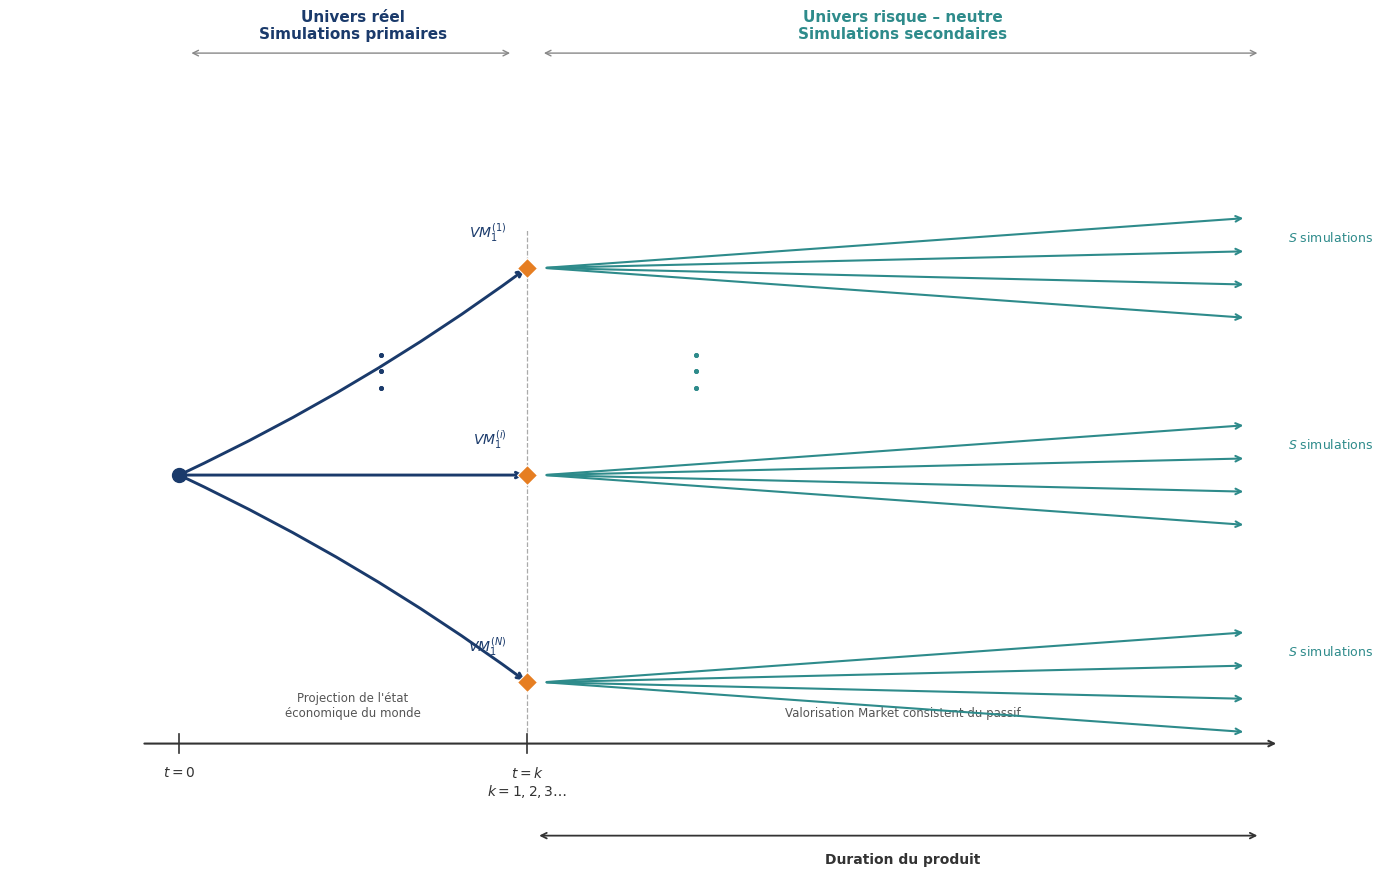

✓ Sauvegardé : sds_diagram.png


In [0]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(-5.2, 6.0)
ax.axis('off')
fig.patch.set_facecolor('white')

COL_PRIMARY   = '#1a3a6b'
COL_SECONDARY = '#2e8b8b'
COL_AXIS      = '#333333'
COL_ANNOT     = '#555555'
COL_DIAMOND   = '#e67e22'

t0   = 1.8
tk   = 5.5
tend = 13.5

# ── Titres avec flèches ───────────────────────────────────────────────
ax.annotate('', xy=(tk - 0.15, 5.5), xytext=(t0 + 0.1, 5.5),
            arrowprops=dict(arrowstyle='<->', color='#888888', lw=1.0))
ax.annotate('', xy=(tend - 0.2, 5.5), xytext=(tk + 0.15, 5.5),
            arrowprops=dict(arrowstyle='<->', color='#888888', lw=1.0))
ax.text((t0 + tk)/2, 5.65,
        'Univers réel\nSimulations primaires',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
        color=COL_PRIMARY, multialignment='center')
ax.text((tk + tend)/2, 5.65,
        'Univers risque – neutre\nSimulations secondaires',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
        color=COL_SECONDARY, multialignment='center')




# ── Axe du temps ─────────────────────────────────────────────────────
y_axis = -3.5
ax.annotate('', xy=(tend, y_axis), xytext=(t0 - 0.4, y_axis),
            arrowprops=dict(arrowstyle='->', color=COL_AXIS, lw=1.5))
for tx, lbl in [(t0, '$t=0$'), (tk, '$t=k$\n$k = 1, 2, 3\\ldots$')]:
    ax.plot([tx, tx], [y_axis - 0.12, y_axis + 0.12], color=COL_AXIS, lw=1.2)
    ax.text(tx, y_axis - 0.28, lbl, ha='center', va='top', fontsize=10,
            color=COL_AXIS)

# Textes sous l'axe
ax.text((t0 + tk)/2, y_axis + 0.32,
        "Projection de l'état\néconomique du monde",
        ha='center', va='bottom', fontsize=8.5, color=COL_ANNOT,
        multialignment='center')
ax.text((tk + tend)/2, y_axis + 0.32,
        "Valorisation Market consistent du passif",
        ha='center', va='bottom', fontsize=8.5, color=COL_ANNOT)


# Duration du produit
y_dur = y_axis - 1.2
ax.annotate('', xy=(tend - 0.2, y_dur), xytext=(tk + 0.1, y_dur),
            arrowprops=dict(arrowstyle='<->', color=COL_AXIS, lw=1.3))
ax.text((tk + tend)/2, y_dur - 0.22, 'Duration du produit',
        ha='center', va='top', fontsize=10, color=COL_AXIS, fontweight='bold')

# Tiret vertical à t=k
ax.plot([tk, tk], [y_axis + 0.15, 3.2],
        color='#aaaaaa', lw=0.9, ls='--')




# ── Origine ───────────────────────────────────────────────────────────
origin = (t0, 0.0)
ax.plot(*origin, 'o', color=COL_PRIMARY, ms=10, zorder=6)

# ── Définition des groupes ────────────────────────────────────────────
# (y_end, label, is_dots_row)
groups = [
    (2.7,  r'$VM_1^{(1)}$',  False),
    (None, None,              True),
    (0.0,  r'$VM_1^{(i)}$',  False),
    (None, None,              True),
    (-2.7, r'$VM_1^{(N)}$',  False),
]

labeled_groups = [(y, lbl) for y, lbl, d in groups if not d]

# ── Pour chaque scénario primaire ─────────────────────────────────────
for y_end, label, is_dots in groups:

    # --- "..." verticaux ---
    if is_dots:
        idx = groups.index((y_end, label, is_dots))
        y_above = groups[idx - 1][0]
        y_below = next(g[0] for g in groups[idx+1:] if not g[2])
        y_mid = (y_above + y_below) / 2

        # "..." côté primaire
        x_dots = (t0 + tk) / 2 + 0.3
        for dy in [-0.22, 0, 0.22]:
            ax.plot(x_dots, y_mid + dy, '.', color=COL_PRIMARY, ms=5, zorder=7)

        # "..." côté secondaire
        x_dots2 = tk + 1.8
        for dy in [-0.22, 0, 0.22]:
            ax.plot(x_dots2, y_mid + dy, '.', color=COL_SECONDARY, ms=5, zorder=7)
        continue

    # --- Trajectoire primaire ---
    rad = 0.055 * (y_end / 3.0)
    ax.annotate('', xy=(tk, y_end), xytext=origin,
                arrowprops=dict(
                    arrowstyle='->', color=COL_PRIMARY, lw=2.1,
                    connectionstyle=f'arc3,rad={rad}'
                ))

    # --- Diamond orange ---
    ax.plot(tk, y_end, 'D', color=COL_DIAMOND, ms=10, zorder=9,
            markeredgecolor='white', markeredgewidth=0.8)

    # --- Label VM₁⁽ⁿ⁾ ---
    ax.text(tk - 0.22, y_end + 0.32, label,
            fontsize=10, color=COL_PRIMARY, ha='right', va='bottom',
            style='italic', fontweight='bold')

    # --- Fan de trajectoires secondaires ---
    n_sec = 4
    half_spread = 0.65

    for j in range(n_sec):
        frac  = j / (n_sec - 1)
        y_tip = y_end + half_spread * (frac * 2 - 1)
        ax.annotate('', xy=(tend - 0.35, y_tip),
                    xytext=(tk + 0.18, y_end),
                    arrowprops=dict(
                        arrowstyle='->', color=COL_SECONDARY, lw=1.5,
                        connectionstyle='arc3,rad=0.0'
                    ))

# ── Labels "S simulations" ────────────────────────────────────────────
for y, _ in labeled_groups:
    ax.text(tend + 0.1, y + 0.4, '$S$ simulations',
            ha='left', va='center', fontsize=9, color=COL_SECONDARY)

plt.tight_layout()
plt.savefig('sds_diagram.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Sauvegardé : sds_diagram.png")


---
## Section 10 — Algorithme LSMC — implémentation pas-à-pas (4 étapes)

```
ÉTAPE 1 : Outer simulation  (t₀ → t₁, mesure physique P)
ÉTAPE 2 : Inner simulation  (t₁ → T,  mesure risque-neutre Q) + nested MC
ÉTAPE 3 : Régression OLS polynomiale
ÉTAPE 4 : Prédiction VM₁ = f̂(S₁)
```


### 10.1 — Paramètres LSMC

In [0]:
# ─── Paramètres LSMC ──────────────────────────────────────────────────
N_OUTER     = 10000    # P : nb de scénarios outer
N_INNER     = 1    # K : nb de inner paths par scénario
POLY_DEGREE = 4       # degré du polynôme de régression
# -------------------------
DECREMENT_VAL_NEUTRE  = 50.0    # ← décrement neutre (pricing) — indépendant du réel
DECREMENT_MODE_NEUTRE = "cum"
# Có thể khác với décrement inner (neutre)
DECREMENT_VAL_REEL  = 50.0    # ← décrement réel (ORSA)
DECREMENT_MODE_REEL = "cum"
# -------------------------

print(f"Paramètres LSMC :")
print(f"  P (outer)      = {N_OUTER:,}")
print(f"  K (inner)      = {N_INNER:,}")
print(f"  Total sims ≈   {N_OUTER*N_INNER:,}")
print(f"  Dégré polynôme = {POLY_DEGREE}")


Paramètres LSMC :
  P (outer)      = 10,000
  K (inner)      = 1
  Total sims ≈   10,000
  Dégré polynôme = 4


---
### Étape 1 — Outer simulation (t₀ → t₁, mesure physique P)

On simule $P$ trajectoires du sous-jacent sur **1 an** sous la **mesure physique $\mathbb{P}$** avec drift $\mu$ :

$$S_t = S_0 \cdot \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

**Pourquoi mesure $\mathbb{P}$ ici ?**  
Dans le cadre ORSA / business planning, les outer paths représentent les **états du monde réels** possibles à $t=1$. On utilise donc le drift historique $\mu$ (pas $r$).

On extrait ensuite $S_1^{(i)}$ = valeur à la dernière colonne du DataFrame.


In [0]:
print("=" * 55)
print("ÉTAPE 1 — Simulation outer (t₀ → t₁)")
print("=" * 55)

n_months_outer = _months_to_reach(DATE_VAL_T0, DATE_VAL_T1)
print(f"  n_months_outer = {n_months_outer} mois")

outer_paths = simulate_gbm_monthly(
    s0          = S0_T0,
    r_annual_cc = MU_OUTER,      # ← drift PHYSIQUE µ (pas r)
    sigma_annual= SIGMA_ANNUAL,
    start_date  = str(DATE_VAL_T0.date()),
    n_months    = n_months_outer,
    n_sims      = N_OUTER,
    seed        = SEED_OUTER,
)

# S₁⁽ⁱ⁾ = dernière colonne (valeur à t₁)
s1_outer = outer_paths.iloc[:, -1].values.astype(float)  # shape (N_OUTER,)

print(f"  outer_paths shape : {outer_paths.shape}")
print(f"  S₁ — mean : {s1_outer.mean():.2f}")
print(f"  S₁ — std  : {s1_outer.std():.2f}")
print(f"  S₁ — min  : {s1_outer.min():.2f}")
print(f"  S₁ — max  : {s1_outer.max():.2f}")


ÉTAPE 1 — Simulation outer (t₀ → t₁)
  n_months_outer = 14 mois
  outer_paths shape : (10000, 15)
  S₁ — mean : 1142.68
  S₁ — std  : 266.34
  S₁ — min  : 478.48
  S₁ — max  : 2699.86


In [0]:
print("=" * 55)
print("ÉTAPE 1b — Décrement outer (t₀ → t₁, décrement réel)")
print("=" * 55)

# Tham số décrement cho outer paths (mesure réelle / ORSA)


outer_paths_dec = decrement_paths(
    outer_paths,
    decrement_value  = DECREMENT_VAL_REEL,
    periods_per_year = 12,
    mode             = DECREMENT_MODE_REEL,
    offset_periods   = 0,        # outer part de t₀ → offset = 0
)

# S₁ decremented — lấy từ cột cuối
s1_outer = outer_paths_dec.iloc[:, -1].values.astype(float)

print(f"  DECREMENT_VAL_REEL  = {DECREMENT_VAL_REEL} pts/an")
print(f"  outer_paths_dec shape : {outer_paths_dec.shape}")
print(f"  S₁ (après décrement) — mean : {s1_outer.mean():.2f}")

ÉTAPE 1b — Décrement outer (t₀ → t₁, décrement réel)
  DECREMENT_VAL_REEL  = 50.0 pts/an
  outer_paths_dec shape : (10000, 15)
  S₁ (après décrement) — mean : 1084.35


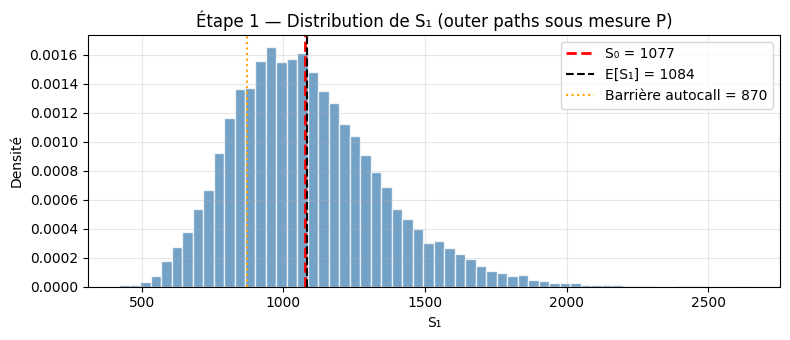

  Prop. S₁ ≥ barrière autocall (870) : 78.4%


In [0]:
# Visualisation de la distribution de S₁
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(s1_outer, bins=60, color="steelblue", alpha=0.75, edgecolor="white", density=True)
ax.axvline(S0_T0,          color="red",   lw=2,   ls="--", label=f"S₀ = {S0_T0:.0f}")
ax.axvline(s1_outer.mean(),color="black", lw=1.5, ls="--", label=f"E[S₁] = {s1_outer.mean():.0f}")
ax.axvline(BARRIERE_AUTOCALL * S_REF, color="orange", lw=1.5, ls=":", label=f"Barrière autocall = {BARRIERE_AUTOCALL*S_REF:.0f}")
ax.set_xlabel("S₁")
ax.set_ylabel("Densité")
ax.set_title("Étape 1 — Distribution de S₁ (outer paths sous mesure P)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"  Prop. S₁ ≥ barrière autocall ({BARRIERE_AUTOCALL*S_REF:.0f}) : {(s1_outer >= BARRIERE_AUTOCALL*S_REF).mean():.1%}")


---
### Étape 2 — Inner simulation + nested MC (t₁ → T, mesure Q)

Pour chaque scénario outer $i = 1, \ldots, P$ :

**a)** Simuler $K$ trajectoires inner depuis $S_1^{(i)}$ sous **mesure risque-neutre $Q$** :
$$S_t = S_1^{(i)} \cdot \exp\!\left[\left(r - \frac{\sigma^2}{2}\right)(t-1) + \sigma (W_t - W_1)\right]$$

**b)** Appliquer `decrement_paths` avec `offset_periods = 12` — car on est déjà à $t=1$ an (12 mois écoulés depuis $t_0$) :
$$\text{dec}(k) = (12 + k) \times \frac{50}{12}$$

**c)** Calculer le payoff via `Payoff(...)` — **même fonction que pour VM₀**, inchangée.

**d)** Calculer $\text{VM}^{(i)}$ via `VM(date\_valuation=t_1)` — **même fonction**, inchangée.

→ On obtient `vm1_nested[i]` = estimation de $\mathbb{E}^Q[\text{CF} \mid S_1^{(i)}]$.

> **Note importante :** les inner paths utilisent toujours la **mesure Q** (drift $r$) car on calcule une espérance actualisée (pricing). La distinction P/Q est fondamentale en Solvabilité II.


In [0]:
print("=" * 55)
print("ÉTAPE 2 — Inner simulation + nested MC")
print(f"  ({N_OUTER} scénarios × {N_INNER} inner paths)")
print("=" * 55)

maturity_theo  = DATE_DEBUT + pd.DateOffset(years=ANNEE_FINALE)
n_months_inner = _months_to_reach(DATE_VAL_T1, maturity_theo)

# Offset = nb de mois entre t₀ et t₁ (pour continuer le décrement)
offset_at_t1 = int(round(
    (DATE_VAL_T1.year  - DATE_VAL_T0.year)  * 12
    + (DATE_VAL_T1.month - DATE_VAL_T0.month)
))

print(f"  n_months_inner = {n_months_inner} mois (t₁ → maturité)")
print(f"  offset_periods = {offset_at_t1} mois (décrement continu depuis t₀)")
print()

rng_inner  = np.random.default_rng(SEED_INNER)
vm1_nested = np.zeros(N_OUTER)

for i in range(N_OUTER):

    # ── a) Simulation inner sous mesure Q ───────────────────────────
    inner_paths = simulate_gbm_monthly(
        s0          = float(s1_outer[i]),
        r_annual_cc = R_NEUTRE_CC,           # ← TOUJOURS mesure Q pour pricing
        sigma_annual= SIGMA_ANNUAL,
        start_date  = str(DATE_VAL_T1.date()),
        n_months    = int(n_months_inner),
        n_sims      = int(N_INNER),
        seed        = int(rng_inner.integers(0, 2**31)),
    )


    # ── b) Décrement NEUTRE inner avec offset ────────────────────────────
    inner_paths_dec = decrement_paths(
        inner_paths,
        decrement_value  = DECREMENT_VAL_NEUTRE,    # ← NEUTRE, indépendant
        periods_per_year = 12,
        mode             = DECREMENT_MODE_NEUTRE,
        offset_periods   = offset_at_t1,
    )

    # ── c) Payoff contractuel ────────────────────────────────────────
    pay_i = Payoff(
        paths                   = inner_paths_dec,
        date_debut              = DATE_DEBUT,
        s_ref                   = S_REF,
        barriere_sortie_anticipe= BARRIERE_AUTOCALL,
        barriere_sortie_maturite= BARRIERE_FINAL,
        barriere_protection     = BARRIERE_PROTECTION,
        premiere_annee_sortie   = PREMIERE_ANNEE_SORTIE,
        freq_sortie             = FREQ_SORTIE,
        coupon_par_periode      = COUPON_PAR_PERIODE,
        annee_finale            = ANNEE_FINALE,
        day_count               = DAY_COUNT,
    )

    # ── d) VM à t₁ ──────────────────────────────────────────────────
    _, vm_i = VM(
        payoff_table   = pay_i,
        courbe_taux    = taux_df,
        date_valuation = DATE_VAL_T1,
        compounding    = COMPOUNDING,
        day_count      = DAY_COUNT,
    )
    vm1_nested[i] = vm_i

    # Progression
    if (i + 1) % (N_OUTER // 5) == 0:
        pct = (i+1)/N_OUTER*100
        print(f"  [{pct:5.1f}%]  scénario {i+1:>5}/{N_OUTER}"
              f"  |  VM₁ running mean = {vm1_nested[:i+1].mean():.4f}")

print(f"\n Nested MC terminé")
print(f"  VM₁ nested — mean = {vm1_nested.mean():.4f}")
print(f"  VM₁ nested — std  = {vm1_nested.std():.4f}")


ÉTAPE 2 — Inner simulation + nested MC
  (10000 scénarios × 1 inner paths)
  n_months_inner = 106 mois (t₁ → maturité)
  offset_periods = 12 mois (décrement continu depuis t₀)

  [ 20.0%]  scénario  2000/10000  |  VM₁ running mean = 1033.0316
  [ 40.0%]  scénario  4000/10000  |  VM₁ running mean = 1041.2353
  [ 60.0%]  scénario  6000/10000  |  VM₁ running mean = 1040.2810
  [ 80.0%]  scénario  8000/10000  |  VM₁ running mean = 1038.4373
  [100.0%]  scénario 10000/10000  |  VM₁ running mean = 1038.4206

 Nested MC terminé
  VM₁ nested — mean = 1038.4206
  VM₁ nested — std  = 347.8064


---
### Étape 3 — Régression OLS polynomiale

On approxime la fonction $\text{VM}_1 = f(S_1)$ par un polynôme de degré $m$ :

$$\hat{f}(x) = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_m x^m$$

où $x = S_1^{(i)} / S_{\text{ref}}$ (variable normalisée — même référence que les barrières).

**Ajustement :** minimisation de $\sum_i (\text{VM}_{1,\text{nested}}^{(i)} - \hat{f}(x^{(i)}))^2$ par OLS.

**Implémentation :** `numpy.linalg.lstsq` — stable numériquement, sans dépendance externe.


In [0]:
print("=" * 55)
print("ÉTAPE 3 — Régression OLS polynomiale")
print("=" * 55)

# Variable explicative normalisée : x = S₁ / S_ref
x_reg = s1_outer / float(S_REF)   # shape (N_OUTER,)

# Matrice de Vandermonde : colonnes = [1, x, x², ..., xᵐ]
X_poly = np.column_stack([x_reg ** k for k in range(POLY_DEGREE + 1)])
# shape : (N_OUTER, POLY_DEGREE+1)

print(f"  X_poly shape : {X_poly.shape}")
print(f"  y (vm1_nested) shape : {vm1_nested.shape}")

# OLS via numpy.linalg.lstsq
beta, residuals, rank, sv = np.linalg.lstsq(X_poly, vm1_nested, rcond=None)

vm1_fitted = X_poly @ beta   # valeurs ajustées

# R²
ss_res = np.sum((vm1_nested - vm1_fitted) ** 2)
ss_tot = np.sum((vm1_nested - vm1_nested.mean()) ** 2)
R2     = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

print(f"\n  Coefficients β :")
for k, b in enumerate(beta):
    print(f"    β_{k} = {b:.6f}")
print(f"\n  R²  = {R2:.6f}")
print(f"  RMSE= {np.sqrt(ss_res / N_OUTER):.4f}")


ÉTAPE 3 — Régression OLS polynomiale
  X_poly shape : (10000, 5)
  y (vm1_nested) shape : (10000,)

  Coefficients β :
    β_0 = -1682.295324
    β_1 = 6338.445722
    β_2 = -5209.908492
    β_3 = 1851.384217
    β_4 = -239.768165

  R²  = 0.118766
  RMSE= 326.4999


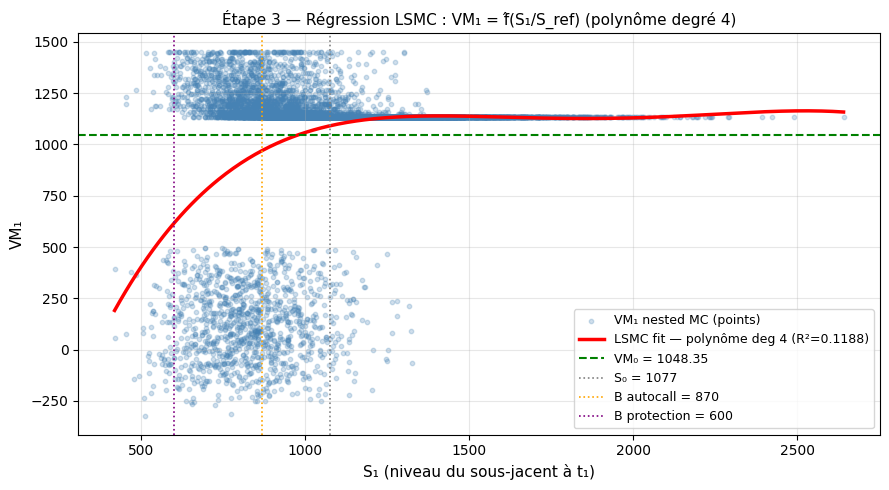

In [0]:
# Visualisation : scatter + courbe de régression
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(s1_outer, vm1_nested, alpha=0.25, s=10,
           color="steelblue", label="VM₁ nested MC (points)")

s1_grid     = np.linspace(s1_outer.min(), s1_outer.max(), 400)
x_grid_norm = s1_grid / float(S_REF)
X_grid_poly = np.column_stack([x_grid_norm ** k for k in range(POLY_DEGREE + 1)])
vm1_grid    = np.maximum(X_grid_poly @ beta, 0.0)

ax.plot(s1_grid, vm1_grid, "r-", lw=2.5,
        label=f"LSMC fit — polynôme deg {POLY_DEGREE} (R²={R2:.4f})")

ax.axhline(VM0, color="green", ls="--", lw=1.5, label=f"VM₀ = {VM0:.2f}")
ax.axvline(S0_T0, color="gray", ls=":", lw=1.2, label=f"S₀ = {S0_T0:.0f}")

for b_val, b_name, col in [
    (BARRIERE_AUTOCALL*S_REF, "B autocall", "orange"),
    (BARRIERE_PROTECTION*S_REF, "B protection", "purple"),
]:
    ax.axvline(b_val, color=col, ls=":", lw=1.2, label=f"{b_name} = {b_val:.0f}")

ax.set_xlabel("S₁ (niveau du sous-jacent à t₁)", fontsize=11)
ax.set_ylabel("VM₁", fontsize=11)
# ax.set_title(f"Étape 3 — Régression LSMC : VM₁ = f̂(S₁/S_ref)")
# (polynôme degré {POLY_DEGREE})", fontsize=11)
ax.set_title(f"Étape 3 — Régression LSMC : VM₁ = f̂(S₁/S_ref) (polynôme degré {POLY_DEGREE})", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
### Étape 4 — Prédiction VM₁ = f̂(S₁)

On applique la fonction ajustée $\hat{f}$ à tous les scénarios outer pour obtenir la **distribution de VM₁** :

$$\text{VM}_1^{(i)} = \hat{f}\!\left(S_1^{(i)} / S_{\text{ref}}\right) = \max\!\left(X_{\text{poly}}^{(i)} \cdot \hat{\beta},\; 0\right)$$

Le $\max(\cdot, 0)$ assure la non-négativité économique de la valeur.


In [0]:
print("=" * 55)
print("ÉTAPE 4 — Prédiction VM₁ LSMC")
print("=" * 55)

# Prédiction sur tous les outer scénarios
vm1_lsmc = np.maximum(X_poly @ beta, 0.0)  # shape (N_OUTER,)

# Statistiques descriptives
q5, q25, q50, q75, q95 = np.percentile(vm1_lsmc, [5, 25, 50, 75, 95])

print(f"\n  Distribution de VM₁ LSMC :")
print(f"  ── Moyenne    = {vm1_lsmc.mean():.4f}")
print(f"  ── Écart-type = {vm1_lsmc.std():.4f}")
print(f"  ── Q5%        = {q5:.4f}   (VaR 95%)")
print(f"  ── Q25%       = {q25:.4f}")
print(f"  ── Médiane    = {q50:.4f}")
print(f"  ── Q75%       = {q75:.4f}")
print(f"  ── Q95%       = {q95:.4f}")
print()
print(f"  Rappel VM₀    = {VM0:.4f}")
print(f"  Variation moy = {(vm1_lsmc.mean()-VM0)/VM0:+.2%}")


ÉTAPE 4 — Prédiction VM₁ LSMC

  Distribution de VM₁ LSMC :
  ── Moyenne    = 1038.4206
  ── Écart-type = 119.8627
  ── Q5%        = 788.8525   (VaR 95%)
  ── Q25%       = 991.0497
  ── Médiane    = 1082.7026
  ── Q75%       = 1127.9748
  ── Q95%       = 1138.7336

  Rappel VM₀    = 1048.3464
  Variation moy = -0.95%


In [0]:
# Choc -39% đúng chuẩn: áp trên S0, không phải S_ref
S1_choc = 0.61 * S0_T0
x1_choc = S1_choc / S_REF

X_choc = np.array([x1_choc ** k for k in range(POLY_DEGREE + 1)])
VM1_choc_lsmc = max(X_choc @ beta, 0.0)

delta_vm_lineaire = VM0 * 0.39
delta_vm_lsmc = VM0 - VM1_choc_lsmc
ecart_pct = (delta_vm_lineaire - delta_vm_lsmc) / delta_vm_lineaire * 100

print(f"S1_choc (niveau réel)     = {S1_choc:.4f}")
print(f"x1_choc (normalisé)       = {x1_choc:.4f}")
print(f"VM1_LSMC(x1_choc)         = {VM1_choc_lsmc:.4f}")
print(f"ΔVM_linéaire              = {delta_vm_lineaire:.4f}")
print(f"ΔVM_LSMC                  = {delta_vm_lsmc:.4f}")
print(f"Écart (%)                 = {ecart_pct:.4f}")

S1_choc (niveau réel)     = 657.1295
x1_choc (normalisé)       = 0.6571
VM1_LSMC(x1_choc)         = 713.7877
ΔVM_linéaire              = 408.8551
ΔVM_LSMC                  = 334.5587
Écart (%)                 = 18.1718


### 10.6 — Visualisation synthétique des résultats (pas-à-pas)

/home/spark-59d9173b-7e81-4a73-9cec-1a/.ipykernel/71/command-5024114003350020-3911746488:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


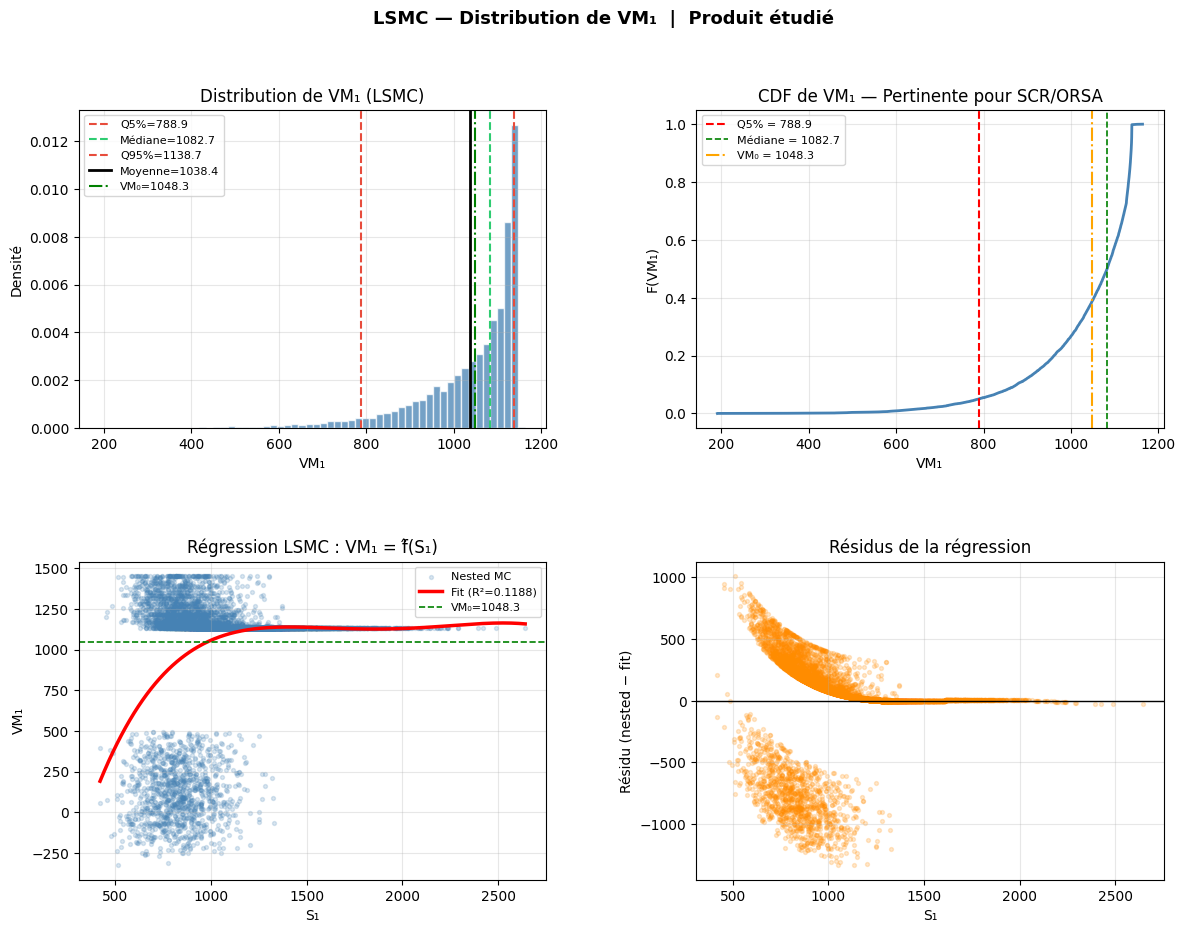

✓ Figure sauvegardée : lsmc_results.png


In [0]:
fig = plt.figure(figsize=(14, 10))
# fig.suptitle(f"LSMC — Distribution de VM₁  |  {row['Libellé']}",
#              fontsize=13, fontweight="bold")
fig.suptitle(f"LSMC — Distribution de VM₁  |  Produit étudié",
             fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── Plot 1 : Distribution VM₁ ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(vm1_lsmc, bins=60, color="steelblue", alpha=0.75, edgecolor="white", density=True)
for qv, ql, col in [(q5,"Q5%","#e74c3c"),(q50,"Médiane","#2ecc71"),(q95,"Q95%","#e74c3c")]:
    ax1.axvline(qv, color=col, ls="--", lw=1.5, label=f"{ql}={qv:.1f}")
ax1.axvline(vm1_lsmc.mean(), color="black", lw=2, label=f"Moyenne={vm1_lsmc.mean():.1f}")
ax1.axvline(VM0, color="green", ls="-.", lw=1.5, label=f"VM₀={VM0:.1f}")
ax1.set_xlabel("VM₁"); ax1.set_ylabel("Densité")
ax1.set_title("Distribution de VM₁ (LSMC)")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# ── Plot 2 : CDF ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
vm1_sorted = np.sort(vm1_lsmc)
cdf = np.arange(1, N_OUTER+1) / N_OUTER
ax2.plot(vm1_sorted, cdf, color="steelblue", lw=2)
ax2.axvline(q5,   color="red",   ls="--", lw=1.5, label=f"Q5% = {q5:.1f}")
ax2.axvline(q50,  color="green", ls="--", lw=1.2, label=f"Médiane = {q50:.1f}")
ax2.axvline(VM0,  color="orange",ls="-.", lw=1.5, label=f"VM₀ = {VM0:.1f}")
ax2.set_xlabel("VM₁"); ax2.set_ylabel("F(VM₁)")
ax2.set_title("CDF de VM₁ — Pertinente pour SCR/ORSA")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── Plot 3 : Régression (rappel) ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(s1_outer, vm1_nested, alpha=0.2, s=8, color="steelblue", label="Nested MC")
ax3.plot(s1_grid, vm1_grid, "r-", lw=2.5, label=f"Fit (R²={R2:.4f})")
ax3.axhline(VM0, color="green", ls="--", lw=1.2, label=f"VM₀={VM0:.1f}")
ax3.set_xlabel("S₁"); ax3.set_ylabel("VM₁")
ax3.set_title("Régression LSMC : VM₁ = f̂(S₁)")
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# ── Plot 4 : Résidus ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
residus = vm1_nested - (X_poly @ beta)
ax4.scatter(s1_outer, residus, alpha=0.2, s=8, color="darkorange")
ax4.axhline(0, color="black", lw=1)
ax4.set_xlabel("S₁"); ax4.set_ylabel("Résidu (nested − fit)")
ax4.set_title("Résidus de la régression")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lsmc_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : lsmc_results.png")


---
## Section 11 — Fonctions réutilisables (packagées)

Toute la logique des 4 étapes est encapsulée dans une fonction unique,  
**avec la même interface que `Payoff()` et `VM()` du code original**.


In [0]:
def lsmc_vm1_single_product(
    # ── Paramètres contractuels (identiques à Payoff) ─────────────────
    date_debut: str | pd.Timestamp,
    s_ref: float,
    barriere_sortie_anticipe: float,
    barriere_sortie_maturite: float,
    barriere_protection: float,
    premiere_annee_sortie: int,
    freq_sortie: FreqSortie,
    coupon_par_periode: float,
    annee_finale: int,
    # ── Paramètres de marché ──────────────────────────────────────────
    s0_t0: float,
    r_neutre_cc: float,
    sigma_annual: float,
    courbe_taux: pd.DataFrame,
    # ── Dates ─────────────────────────────────────────────────────────
    date_valuation_t0: str | pd.Timestamp,
    date_valuation_t1: str | pd.Timestamp,
    # ── LSMC ──────────────────────────────────────────────────────────
    n_outer: int = 1000,
    n_inner: int = 1000,
    mu_outer: Optional[float] = None,
    poly_degree: int = 3,
    # ── Simulation (identiques à price_products_pipeline) ─────────────
    # ── Décrement RÉEL (outer — mesure P / ORSA)/NEUTRE (inner — mesure Q / pricing) ──────────────────────
    decrement_value_reel: float = 50.0,
    decrement_value_neutre: float = 50.0,
    decrement_mode: DecrementMode = "cum",

    periods_per_year: int = 12,
    compounding: Compounding = "annual",
    day_count: int = 365,
    seed_outer: int = 42,
    seed_inner: int = 123,
    verbose: bool = True,
) -> dict:
    """
    LSMC — Estimation de la distribution de VM₁ pour un produit SAF.

    Réutilise EXACTEMENT Payoff() + VM() du code original.
    Seule nouveauté : offset_periods dans decrement_paths pour les inner paths.

    Returns : dict avec vm1_lsmc, vm1_nested, s1_outer, beta_coef, r2, ...
    """
    t0 = pd.to_datetime(date_valuation_t0)
    t1 = pd.to_datetime(date_valuation_t1)
    d0 = pd.to_datetime(date_debut)
    mat = d0 + pd.DateOffset(years=annee_finale)
    drift_out = mu_outer if mu_outer is not None else r_neutre_cc

    if verbose:
        print("="*55)
        print("LSMC — VM₁ prospective")
        print(f"  t₀={t0.date()} S₀={s0_t0:.2f} | t₁={t1.date()}")
        print(f"  P={n_outer}, K={n_inner}, degré={poly_degree}")
        print("="*55)

    # ÉTAPE 1 — Outer
    out_paths = simulate_gbm_monthly(s0=s0_t0, r_annual_cc=drift_out,
        sigma_annual=sigma_annual, start_date=str(t0.date()),
        n_months=_months_to_reach(t0, t1), n_sims=n_outer, seed=seed_outer)


    # ÉTAPE 1b — Décrement RÉEL outer
    out_paths_dec = decrement_paths(
        out_paths,
        decrement_value  = decrement_value_reel,
        periods_per_year = periods_per_year,
        mode             = decrement_mode,
        offset_periods   = 0,
    )
    s1 = out_paths_dec.iloc[:, -1].values.astype(float)

    # ÉTAPE 2 — Inner + nested MC
    n_months_in = _months_to_reach(t1, mat)
    offset_t1   = int(round((t1.year-t0.year)*12 + (t1.month-t0.month)))
    rng = np.random.default_rng(seed_inner)
    vm1_n = np.zeros(n_outer)

    for i in range(n_outer):
        in_paths = simulate_gbm_monthly(
            s0=float(s1[i]), r_annual_cc=r_neutre_cc, sigma_annual=sigma_annual,
            start_date=str(t1.date()), n_months=n_months_in, n_sims=n_inner,
            seed=int(rng.integers(0, 2**31)))
        in_dec = decrement_paths(in_paths, decrement_value=decrement_value_neutre,
            periods_per_year=periods_per_year, mode=decrement_mode, offset_periods=offset_t1)
        pay_i = Payoff(in_dec, date_debut=d0, s_ref=s_ref,
            barriere_sortie_anticipe=barriere_sortie_anticipe,
            barriere_sortie_maturite=barriere_sortie_maturite,
            barriere_protection=barriere_protection,
            premiere_annee_sortie=premiere_annee_sortie, freq_sortie=freq_sortie,
            coupon_par_periode=coupon_par_periode, annee_finale=annee_finale, day_count=day_count)
        _, vm1_n[i] = VM(pay_i, courbe_taux, date_valuation=t1,
            compounding=compounding, day_count=day_count)
        if verbose and (i+1) % max(1, n_outer//5) == 0:
            print(f"  [{(i+1)/n_outer:5.1%}]  running mean = {vm1_n[:i+1].mean():.4f}")

    # ÉTAPE 3 — Régression OLS
    x    = s1 / float(s_ref)
    Xp   = np.column_stack([x**k for k in range(poly_degree+1)])
    beta, _, _, _ = np.linalg.lstsq(Xp, vm1_n, rcond=None)
    fit  = Xp @ beta
    ss_r = np.sum((vm1_n - fit)**2)
    ss_t = np.sum((vm1_n - vm1_n.mean())**2)
    r2   = float(1 - ss_r/ss_t) if ss_t > 0 else 0.0

    # ÉTAPE 4 — Prédiction
    vm1_l = np.maximum(fit, 0.0)
    qs    = {f"{p}%": float(np.percentile(vm1_l, p)) for p in [5, 25, 50, 75, 95]}

    if verbose:
        print(f"\n  R² = {r2:.6f}")
        print(f"  VM₁ mean = {vm1_l.mean():.4f}  |  std = {vm1_l.std():.4f}")
        print(f"  Q5%={qs['5%']:.4f}  médiane={qs['50%']:.4f}  Q95%={qs['95%']:.4f}")

    return {"vm1_lsmc": vm1_l, "vm1_nested": vm1_n, "s1_outer": s1,
            "beta_coef": beta, "r2": r2,
            "vm1_mean": float(vm1_l.mean()), "vm1_std": float(vm1_l.std()),
            "vm1_quantiles": qs, "poly_degree": poly_degree, "s_ref": float(s_ref)}

print("✓ lsmc_vm1_single_product définie")


✓ lsmc_vm1_single_product définie


### Appel de la fonction (vérification de cohérence)

In [0]:
# Vérification : résultats doivent être proches de ce qu'on a calculé étape par étape
result = lsmc_vm1_single_product(
    date_debut              = DATE_DEBUT,
    s_ref                   = S_REF,
    barriere_sortie_anticipe= BARRIERE_AUTOCALL,
    barriere_sortie_maturite= BARRIERE_FINAL,
    barriere_protection     = BARRIERE_PROTECTION,
    premiere_annee_sortie   = PREMIERE_ANNEE_SORTIE,
    freq_sortie             = FREQ_SORTIE,
    coupon_par_periode      = COUPON_PAR_PERIODE,
    annee_finale            = ANNEE_FINALE,
    s0_t0                   = S0_T0,
    r_neutre_cc             = R_NEUTRE_CC,
    sigma_annual            = SIGMA_ANNUAL,
    courbe_taux             = taux_df,
    date_valuation_t0       = DATE_VAL_T0,
    date_valuation_t1       = DATE_VAL_T1,
    n_outer                 = N_OUTER,
    n_inner                 = N_INNER,
    mu_outer                = MU_OUTER,
    poly_degree             = POLY_DEGREE,
    decrement_value_reel    = DECREMENT_VAL_REEL,
    decrement_value_neutre  = DECREMENT_VAL_NEUTRE,
    decrement_mode          = DECREMENT_MODE,
    seed_outer              = SEED_OUTER,
    seed_inner              = SEED_INNER,
)





LSMC — VM₁ prospective
  t₀=2025-12-31 S₀=1077.26 | t₁=2026-12-31
  P=10000, K=1, degré=4
  [20.0%]  running mean = 1033.0316
  [40.0%]  running mean = 1041.2353
  [60.0%]  running mean = 1040.2810
  [80.0%]  running mean = 1038.4373
  [100.0%]  running mean = 1038.4206

  R² = 0.118766
  VM₁ mean = 1038.4206  |  std = 119.8627
  Q5%=788.8525  médiane=1082.7026  Q95%=1138.7336


### 11.2 — `calibrate_lsmc` : pipeline complet paramétrable

In [0]:
def calibrate_lsmc(
    # ── Tham số contractuels (giống hệt Payoff) ───────────────────────
    date_debut: str | pd.Timestamp,
    s_ref: float,
    barriere_sortie_anticipe: float,
    barriere_sortie_maturite: float,
    barriere_protection: float,
    premiere_annee_sortie: int,
    freq_sortie: str,
    coupon_par_periode: float,
    annee_finale: int,
    # ── Tham số thị trường ─────────────────────────────────────────────
    s0_t0: float,
    r_neutre_cc: float,
    sigma_annual: float,
    courbe_taux: pd.DataFrame,
    # ── Dates ──────────────────────────────────────────────────────────
    date_valuation_t0: str | pd.Timestamp,
    date_valuation_t1: str | pd.Timestamp,
    # ── Tham số LSMC ──────────────────────────────────────────────────
    n_outer: int = 10000,
    n_inner: int = 1,
    mu_outer: Optional[float] = None,
    poly_degree: int = 3,
    # ── Décrement RÉEL (outer — mesure P / ORSA) ──────────────────────
    decrement_value_reel: float = 50.0,
    decrement_mode: str = "cum",
    # ── Décrement NEUTRE (inner — mesure Q / pricing) ─────────────────
    decrement_value_neutre: float = 50.0,
    # ── Autres ────────────────────────────────────────────────────────
    periods_per_year: int = 12,
    compounding: str = "annual",
    day_count: int = 365,
    seed_outer: int = 42,
    seed_inner: int = 123,
    verbose: bool = True,
) -> tuple:
    """
    Calibre le modèle LSMC et retourne (f, result).

    USAGE
    -----
    f_vm1, result = calibrate_lsmc(...)

    # Évaluation ponctuelle
    vm1 = f_vm1(950.0)               # scalaire
    vm1_arr = f_vm1(s1_outer)        # array

    # Distribution VM₁
    vm1_dist = result["vm1_lsmc"]    # shape (n_outer,)
    r2       = result["r2"]
    qs       = result["vm1_quantiles"]

    DEUX DÉCREMENTS INDÉPENDANTS
    ----------------------------
    decrement_value_reel   : outer (ORSA, mesure P)
    decrement_value_neutre : inner (pricing, mesure Q)

    RETOURNE
    --------
    (f, result) : tuple
        f      : callable  —  f(S1) → VM1, float ou np.ndarray
        result : dict      —  vm1_lsmc, vm1_nested, s1_outer,
                               beta_coef, r2, vm1_mean, vm1_std,
                               vm1_quantiles, poly_degree, s_ref
    """

    # ── Conversions ────────────────────────────────────────────────────
    t0          = pd.to_datetime(date_valuation_t0)
    t1          = pd.to_datetime(date_valuation_t1)
    d_debut     = pd.to_datetime(date_debut)
    maturity    = d_debut + pd.DateOffset(years=annee_finale)
    drift_outer = mu_outer if mu_outer is not None else r_neutre_cc

    if verbose:
        print("=" * 55)
        print("calibrate_lsmc — calibration de f(S1) → VM1")
        print("=" * 55)
        print(f"  t0 = {t0.date()}  |  S0    = {s0_t0:.4f}")
        print(f"  t1 = {t1.date()}  |  s_ref = {s_ref:.0f}")
        print(f"  maturité = {maturity.date()}")
        print(f"  outer : P={n_outer}, drift={drift_outer:.4f} "
              f"({'mesure P' if mu_outer else 'mesure Q'})")
        print(f"  inner : K={n_inner}, drift={r_neutre_cc:.4f} (mesure Q)")
        print(f"  décr. réel   : {decrement_value_reel} pts/an ({decrement_mode})")
        print(f"  décr. neutre : {decrement_value_neutre} pts/an ({decrement_mode})")
        print(f"  régression : polynôme degré {poly_degree}")
        print()

    # ==================================================================
    # ÉTAPE 1 — Outer simulation (t0 → t1, mesure P)
    # ==================================================================
    if verbose:
        print("► Étape 1 — Outer simulation (t0 → t1)...")

    n_months_outer = _months_to_reach(t0, t1)

    outer_paths = simulate_gbm_monthly(
        s0           = s0_t0,
        r_annual_cc  = drift_outer,
        sigma_annual = sigma_annual,
        start_date   = str(t0.date()),
        n_months     = n_months_outer,
        n_sims       = n_outer,
        seed         = seed_outer,
    )

    # ── ÉTAPE 1b — Décrement RÉEL outer (t0 → t1) ─────────────────────
    outer_paths_dec = decrement_paths(
        outer_paths,
        decrement_value  = float(decrement_value_reel),
        periods_per_year = int(periods_per_year),
        mode             = decrement_mode,
        offset_periods   = 0,        # outer démarre à t₀
    )

    s1 = outer_paths_dec.iloc[:, -1].values.astype(float)   # shape (n_outer,)

    if verbose:
        print(f"   S1 : mean={s1.mean():.2f}  std={s1.std():.2f}"
              f"  min={s1.min():.2f}  max={s1.max():.2f}")
        print()

    # ==================================================================
    # ÉTAPE 2 — Inner simulation + nested MC (t1 → T, mesure Q)
    # ==================================================================
    if verbose:
        print(f"► Étape 2 — Inner simulation + nested MC ({n_outer}×{n_inner})...")

    n_months_inner = _months_to_reach(t1, maturity)

    offset_t1 = int(round(
        (t1.year - t0.year) * 12 + (t1.month - t0.month)
    ))

    rng        = np.random.default_rng(seed_inner)
    vm1_nested = np.zeros(n_outer)

    for i in range(n_outer):

        # a) Simulation inner sous mesure Q
        inner_paths = simulate_gbm_monthly(
            s0           = float(s1[i]),       # S₁ decremented du scénario i
            r_annual_cc  = r_neutre_cc,        # TOUJOURS mesure Q pour pricing
            sigma_annual = sigma_annual,
            start_date   = str(t1.date()),
            n_months     = int(n_months_inner),
            n_sims       = int(n_inner),
            seed         = int(rng.integers(0, 2**31)),
        )

        # b) Décrement NEUTRE inner avec offset (continuer depuis t1)
        inner_dec = decrement_paths(
            inner_paths,
            decrement_value  = float(decrement_value_neutre),
            periods_per_year = int(periods_per_year),
            mode             = decrement_mode,
            offset_periods   = offset_t1,      # continue depuis t₁, pas reset à 0
        )

        # c) Payoff contractuel
        pay_i = Payoff(
            paths                    = inner_dec,
            date_debut               = d_debut,
            s_ref                    = float(s_ref),
            barriere_sortie_anticipe = float(barriere_sortie_anticipe),
            barriere_sortie_maturite = float(barriere_sortie_maturite),
            barriere_protection      = float(barriere_protection),
            premiere_annee_sortie    = int(premiere_annee_sortie),
            freq_sortie              = freq_sortie,
            coupon_par_periode       = float(coupon_par_periode),
            annee_finale             = int(annee_finale),
            day_count                = int(day_count),
        )

        # d) VM à t1
        _, vm1_nested[i] = VM(
            payoff_table   = pay_i,
            courbe_taux    = courbe_taux,
            date_valuation = t1,
            compounding    = compounding,
            day_count      = day_count,
        )

        if verbose and (i + 1) % max(1, n_outer // 5) == 0:
            print(f"   [{(i+1)/n_outer:5.1%}]  running mean = {vm1_nested[:i+1].mean():.4f}")

    if verbose:
        print(f"\n   vm1_nested : mean={vm1_nested.mean():.4f}  std={vm1_nested.std():.4f}")
        print()

    # ==================================================================
    # ÉTAPE 3 — Régression OLS polynomiale
    # ==================================================================
    if verbose:
        print(f"► Étape 3 — Régression OLS (polynôme degré {poly_degree})...")

    x_reg  = s1 / float(s_ref)
    X_poly = np.column_stack([x_reg ** k for k in range(poly_degree + 1)])

    beta, _, _, _ = np.linalg.lstsq(X_poly, vm1_nested, rcond=None)

    fitted = X_poly @ beta
    ss_res = np.sum((vm1_nested - fitted) ** 2)
    ss_tot = np.sum((vm1_nested - vm1_nested.mean()) ** 2)
    r2     = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

    if verbose:
        print(f"   β = {np.round(beta, 4)}")
        print(f"   R² = {r2:.6f}")
        print()

    # ==================================================================
    # ÉTAPE 4 — Distribution VM₁ + callable f(S1)
    # ==================================================================

    vm1_lsmc = np.maximum(fitted, 0.0)
    qs = {f"{p}%": float(np.percentile(vm1_lsmc, p)) for p in [5, 25, 50, 75, 95]}

    # Closure : capture beta, poly_degree, s_ref
    _beta        = beta.copy()
    _poly_degree = poly_degree
    _s_ref       = float(s_ref)

    def f(S1):
        """
        f(S1) → VM1 estimée par LSMC.

        Paramètre
        ---------
        S1 : float ou np.ndarray
            Niveau du sous-jacent à t=1 (même unité que s_ref).

        Retourne
        --------
        float ou np.ndarray — VM1 estimée, toujours >= 0.

        Exemples
        --------
        f(950.0)
        f(np.array([800, 900, 1000, 1100]))
        f(s1_outer)
        """
        x   = np.asarray(S1, dtype=float) / _s_ref
        Xp  = np.column_stack([x.ravel() ** k for k in range(_poly_degree + 1)])
        vm1 = np.maximum(Xp @ _beta, 0.0)
        if np.isscalar(S1):
            return float(vm1[0])
        return vm1.reshape(np.asarray(S1).shape)

    if verbose:
        print("► Calibration terminée.")
        print(f"   f({s0_t0:.0f})       = {f(s0_t0):.4f}  (test : S1 = S0)")
        print(f"   f({s0_t0*0.8:.0f})   = {f(s0_t0*0.8):.4f}  (test : S1 = -20%)")
        print(f"   f({s0_t0*1.2:.0f})   = {f(s0_t0*1.2):.4f}  (test : S1 = +20%)")
        print()
        print(f"   Distribution VM₁ :")
        print(f"     mean = {vm1_lsmc.mean():.4f}  |  std = {vm1_lsmc.std():.4f}")
        for k, v in qs.items():
            print(f"     {k:<5} = {v:.4f}")
        print("=" * 55)

    result = {
        "vm1_lsmc"      : vm1_lsmc,        # shape (n_outer,) — distribution VM₁
        "vm1_nested"    : vm1_nested,       # shape (n_outer,) — Y bruts avant OLS
        "s1_outer"      : s1,              # shape (n_outer,) — S₁ decremented
        "beta_coef"     : beta,            # coefficients OLS
        "r2"            : r2,
        "vm1_mean"      : float(vm1_lsmc.mean()),
        "vm1_std"       : float(vm1_lsmc.std()),
        "vm1_quantiles" : qs,
        "poly_degree"   : poly_degree,
        "s_ref"         : _s_ref,
    }

    return f, result

print("✓ calibrate_lsmc définie")

✓ calibrate_lsmc définie


### 11.3 — `plot_lsmc_results` : visualisation standardisée des résultats

In [0]:
def plot_lsmc_results(result: dict, vm0: float = None, s0_t0: float = None):
    """
    Vẽ 4 plots từ kết quả calibrate_lsmc.

    Paramètres
    ----------
    result  : dict retourné par calibrate_lsmc(...)
    vm0     : float (optionnel) — VM₀ pour référence sur les plots
    s0_t0   : float (optionnel) — S₀ pour référence sur les plots

    Usage
    -----
    f_vm1, result = calibrate_lsmc(...)
    plot_lsmc_results(result, vm0=VM0, s0_t0=S0_T0)
    """

    vm1_lsmc   = result["vm1_lsmc"]      # fitted, shape (n_outer,)
    vm1_nested = result["vm1_nested"]    # noisy Y, shape (n_outer,)
    s1_outer   = result["s1_outer"]      # S₁ decremented, shape (n_outer,)
    beta       = result["beta_coef"]
    r2         = result["r2"]
    qs         = result["vm1_quantiles"]
    poly_degree= result["poly_degree"]
    s_ref      = result["s_ref"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("LSMC — Analyse des résultats VM₁", fontsize=14, fontweight="bold", y=1.01)

    # ──────────────────────────────────────────────────────────────────
    # PLOT 1 — Scatter VM₁ vs S₁ + courbe de régression
    # ──────────────────────────────────────────────────────────────────
    ax = axes[0, 0]

    ax.scatter(s1_outer, vm1_nested, alpha=0.15, s=8,
               color="steelblue", label="$Y^{(i)}$ — nested MC (noisy)")
    ax.scatter(s1_outer, vm1_lsmc, alpha=0.15, s=8,
               color="salmon", label="$\\hat{f}(S_1^{(i)})$ — fitted (OLS)")

    # Courbe de régression lisse
    s1_grid  = np.linspace(s1_outer.min(), s1_outer.max(), 500)
    x_grid   = s1_grid / s_ref
    Xg       = np.column_stack([x_grid ** k for k in range(poly_degree + 1)])
    vm1_grid = np.maximum(Xg @ beta, 0.0)
    ax.plot(s1_grid, vm1_grid, "r-", lw=2.5,
            label=f"Régression polynôme deg {poly_degree} (R²={r2:.4f})")

    if vm0 is not None:
        ax.axhline(vm0, color="green", ls="--", lw=1.5, label=f"VM₀ = {vm0:.2f}")
    if s0_t0 is not None:
        ax.axvline(s0_t0, color="gray", ls=":", lw=1.2, label=f"S₀ = {s0_t0:.0f}")

    ax.set_xlabel("$S_1$ (niveau du sous-jacent à $t_1$)")
    ax.set_ylabel("VM₁")
    ax.set_title("Scatter + Courbe de régression")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ──────────────────────────────────────────────────────────────────
    # PLOT 2 — Distribution VM₁ (histogram)
    # ──────────────────────────────────────────────────────────────────
    ax = axes[0, 1]

    ax.hist(vm1_lsmc, bins=60, color="steelblue", alpha=0.75,
            edgecolor="white", density=True)

    # Quantiles
    colors_q = {"5%": "red", "50%": "black", "95%": "red"}
    ls_q     = {"5%": "--", "50%": "-", "95%": "--"}
    for q_label, col in colors_q.items():
        ax.axvline(qs[q_label], color=col, ls=ls_q[q_label], lw=1.8,
                   label=f"Q{q_label} = {qs[q_label]:.2f}")

    if vm0 is not None:
        ax.axvline(vm0, color="green", ls="-.", lw=1.8, label=f"VM₀ = {vm0:.2f}")

    ax.set_xlabel("VM₁")
    ax.set_ylabel("Densité")
    ax.set_title("Distribution de VM₁")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Annotation stats
    ax.text(0.97, 0.97,
            f"mean = {vm1_lsmc.mean():.2f}\nstd  = {vm1_lsmc.std():.2f}",
            transform=ax.transAxes, fontsize=8.5,
            ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    # ──────────────────────────────────────────────────────────────────
    # PLOT 3 — CDF de VM₁
    # ──────────────────────────────────────────────────────────────────
    ax = axes[1, 0]

    vm1_sorted = np.sort(vm1_lsmc)
    cdf        = np.arange(1, len(vm1_sorted) + 1) / len(vm1_sorted)

    ax.plot(vm1_sorted, cdf, color="steelblue", lw=2)

    # Marquer les quantiles
    for q_label, col in [("5%", "red"), ("50%", "black"), ("95%", "red")]:
        q_val = qs[q_label]
        q_cdf = float(q_label.replace("%", "")) / 100
        ax.plot(q_val, q_cdf, "o", color=col, ms=7, zorder=5)
        ax.annotate(f"Q{q_label}\n{q_val:.2f}",
                    xy=(q_val, q_cdf),
                    xytext=(q_val + (vm1_sorted.max()-vm1_sorted.min())*0.04, q_cdf),
                    fontsize=7.5, color=col, va="center")

    if vm0 is not None:
        # Trouver CDF à vm0
        cdf_at_vm0 = float(np.mean(vm1_lsmc <= vm0))
        ax.axvline(vm0, color="green", ls="-.", lw=1.5,
                   label=f"VM₀={vm0:.2f}  →  F={cdf_at_vm0:.1%}")
        ax.legend(fontsize=8)

    ax.set_xlabel("VM₁")
    ax.set_ylabel("F(VM₁)")
    ax.set_title("CDF de VM₁  —  lecture directe des quantiles")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.02)

    # ──────────────────────────────────────────────────────────────────
    # PLOT 4 — Résidus
    # ──────────────────────────────────────────────────────────────────
    ax = axes[1, 1]

    residus = vm1_nested - vm1_lsmc   # Y - fitted

    ax.scatter(s1_outer, residus, alpha=0.15, s=8, color="steelblue")
    ax.axhline(0, color="red", lw=1.5, ls="--")

    # Bande ±2 std résidus
    std_res = residus.std()
    ax.axhline(+2*std_res, color="orange", lw=1, ls=":", label=f"±2σ = ±{2*std_res:.2f}")
    ax.axhline(-2*std_res, color="orange", lw=1, ls=":")

    ax.set_xlabel("$S_1$")
    ax.set_ylabel("Résidu  $(Y^{(i)} - \\hat{f}(S_1^{(i)}))$")
    ax.set_title("Résidus de la régression OLS")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Annotation R²
    ax.text(0.03, 0.97, f"R² = {r2:.6f}",
            transform=ax.transAxes, fontsize=9,
            ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.savefig("lsmc_diagnostic.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Figure sauvegardée : lsmc_diagnostic.png")


print("✓ plot_lsmc_results définie")

✓ plot_lsmc_results définie


### 11.4 — `compare_poly_lsmc` : sélection du degré polynomial (AIC/BIC)

In [0]:
def compare_poly_lsmc(
    result: dict,
    degrees: list = [1, 2, 3, 4, 5, 6],
    plot: bool = True,
    vm0: float = None,
) -> pd.DataFrame:
    """
    Compare plusieurs degrés polynomiaux sur les données déjà simulées.

    NE RESIMULE PAS — réutilise vm1_nested et s1_outer de calibrate_lsmc.

    Paramètres
    ----------
    result  : dict retourné par calibrate_lsmc(...)
    degrees : list de degrés à comparer
    plot    : bool — afficher le graphique comparatif
    vm0     : float (optionnel) — VM₀ pour référence

    Retourne
    --------
    df_metrics : pd.DataFrame
        Colonnes : degree, k, R2, RSS, AIC, BIC
        Trié par AIC croissant.

    Usage
    -----
    f_vm1, result = calibrate_lsmc(...)
    df = compare_poly_lsmc(result, degrees=[1, 2, 3, 4, 5, 6])
    """

    s1         = result["s1_outer"]       # shape (n_outer,)
    y          = result["vm1_nested"]     # shape (n_outer,) — noisy Y
    s_ref      = result["s_ref"]
    deg_base   = result["poly_degree"]    # degré utilisé dans calibrate_lsmc

    n   = len(y)
    x   = s1 / s_ref

    rows     = []
    fits     = {}   # stocke fitted values pour le plot
    betas    = {}   # stocke beta pour chaque degré

    for deg in degrees:
        k      = deg + 1   # nombre de paramètres (β₀ … β_deg)
        X_poly = np.column_stack([x ** d for d in range(k)])

        beta, _, _, _ = np.linalg.lstsq(X_poly, y, rcond=None)
        fitted        = X_poly @ beta

        rss    = float(np.sum((y - fitted) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2     = float(1.0 - rss / ss_tot) if ss_tot > 0 else 0.0

        # AIC et BIC (formule OLS gaussien, sans constante de normalisation)
        aic = n * np.log(rss / n) + 2 * k
        bic = n * np.log(rss / n) + k * np.log(n)

        rows.append({
            "degree" : deg,
            "k"      : k,
            "R2"     : round(r2,  6),
            "RSS"    : round(rss, 4),
            "AIC"    : round(aic, 2),
            "BIC"    : round(bic, 2),
        })
        fits[deg]  = np.maximum(fitted, 0.0)
        betas[deg] = beta

    df_metrics = (
        pd.DataFrame(rows)
        .sort_values("AIC")
        .reset_index(drop=True)
    )

    best_aic = int(df_metrics.loc[df_metrics["AIC"].idxmin(), "degree"])
    best_bic = int(df_metrics.loc[df_metrics["BIC"].idxmin(), "degree"])

    # ── Affichage tableau ──────────────────────────────────────────────
    print("=" * 60)
    print("Comparaison des degrés polynomiaux — AIC / BIC / R²")
    print("=" * 60)
    print(df_metrics.to_string(index=False))
    print()
    print(f"  → Meilleur AIC : degré {best_aic}")
    print(f"  → Meilleur BIC : degré {best_bic}")
    print(f"  → Degré utilisé dans calibrate_lsmc : {deg_base}")
    print("=" * 60)

    # ── Plot ───────────────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle("Comparaison des degrés polynomiaux — LSMC",
                     fontsize=13, fontweight="bold")

        # ── Plot gauche : scatter + toutes les courbes ─────────────────
        ax = axes[0]

        ax.scatter(s1, y, alpha=0.12, s=7, color="lightsteelblue",
                   label="$Y^{(i)}$ nested MC", zorder=1)

        s1_grid  = np.linspace(s1.min(), s1.max(), 500)
        x_grid   = s1_grid / s_ref
        cmap     = plt.cm.plasma
        n_deg    = len(degrees)

        for idx, deg in enumerate(sorted(degrees)):
            k_     = deg + 1
            Xg     = np.column_stack([x_grid ** d for d in range(k_)])
            curve  = np.maximum(Xg @ betas[deg], 0.0)
            color  = cmap(idx / max(n_deg - 1, 1))
            lw     = 2.8 if deg in (best_aic, best_bic) else 1.4
            ls     = "-" if deg in (best_aic, best_bic) else "--"
            label  = f"deg {deg}"
            if deg == best_aic == best_bic:
                label += "  ★ AIC+BIC"
            elif deg == best_aic:
                label += "  ★ AIC"
            elif deg == best_bic:
                label += "  ★ BIC"
            ax.plot(s1_grid, curve, color=color, lw=lw, ls=ls, label=label, zorder=3)

        if vm0 is not None:
            ax.axhline(vm0, color="green", ls="-.", lw=1.5,
                       label=f"VM₀ = {vm0:.2f}", zorder=2)

        ax.set_xlabel("$S_1$")
        ax.set_ylabel("VM₁")
        ax.set_title("Courbes de régression par degré")
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

        # ── Plot droit : AIC et BIC par degré ─────────────────────────
        ax = axes[1]

        deg_list = df_metrics["degree"].tolist()
        aic_list = df_metrics.sort_values("degree")["AIC"].tolist()
        bic_list = df_metrics.sort_values("degree")["BIC"].tolist()
        deg_sorted = df_metrics.sort_values("degree")["degree"].tolist()

        ax.plot(deg_sorted, aic_list, "o-", color="steelblue",
                lw=2, ms=7, label="AIC")
        ax.plot(deg_sorted, bic_list, "s--", color="tomato",
                lw=2, ms=7, label="BIC")

        # Marquer les minima
        ax.axvline(best_aic, color="steelblue", ls=":", lw=1.3,
                   label=f"min AIC → deg {best_aic}")
        ax.axvline(best_bic, color="tomato",    ls=":", lw=1.3,
                   label=f"min BIC → deg {best_bic}")

        ax.set_xlabel("Degré du polynôme")
        ax.set_ylabel("Valeur du critère")
        ax.set_title("AIC et BIC en fonction du degré")
        ax.set_xticks(deg_sorted)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("lsmc_poly_comparison.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("✓ Figure sauvegardée : lsmc_poly_comparison.png")

    return df_metrics


print("✓ compare_poly_lsmc définie")

✓ compare_poly_lsmc définie


---
## Section 12 — Application : calibration LSMC sur le produit étudié

In [0]:

f_vm1, result = calibrate_lsmc(
    # Tham số contractuels — repris des variables extraites à la Section 2
    # (une seule source de vérité : la ligne PRODUIT_LIBELLE dans Data.xlsx)
    date_debut               = DATE_DEBUT,
    s_ref                    = S_REF,
    barriere_sortie_anticipe = BARRIERE_AUTOCALL,
    barriere_sortie_maturite = BARRIERE_FINAL,
    barriere_protection      = BARRIERE_PROTECTION,
    premiere_annee_sortie    = PREMIERE_ANNEE_SORTIE,
    freq_sortie              = FREQ_SORTIE,
    coupon_par_periode       = COUPON_PAR_PERIODE,
    annee_finale             = ANNEE_FINALE,

    # Tham số thị trường — idem, repris des variables
    s0_t0        = S0_T0,
    r_neutre_cc  = R_NEUTRE_CC,
    sigma_annual = SIGMA_ANNUAL,
    courbe_taux  = taux_df,

    # Dates
    date_valuation_t0 = DATE_VAL_T0,
    date_valuation_t1 = DATE_VAL_T1,

    # LSMC
    n_outer      = 10000,
    n_inner      = 1,
    mu_outer     = MU_OUTER,    # drift physique pour ORSA
    poly_degree  = 4,

    # Simulation
    decrement_value_reel   = DECREMENT_VAL,
    decrement_value_neutre = DECREMENT_VAL,
    decrement_mode    = DECREMENT_MODE,
    periods_per_year = 12,
    compounding      = COMPOUNDING,
    day_count        = DAY_COUNT,
)


vm1 = f_vm1(950.0)

# Xem distribution
print(result["vm1_mean"])
print(result["vm1_quantiles"])
vm1_dist = result["vm1_lsmc"]   # array shape (n_outer,) để vẽ histogram


calibrate_lsmc — calibration de f(S1) → VM1
  t0 = 2025-12-31  |  S0    = 1077.2615
  t1 = 2026-12-31  |  s_ref = 1000
  maturité = 2035-08-08
  outer : P=10000, drift=0.0526 (mesure P)
  inner : K=1, drift=0.0526 (mesure Q)
  décr. réel   : 50.0 pts/an (cum)
  décr. neutre : 50.0 pts/an (cum)
  régression : polynôme degré 4

► Étape 1 — Outer simulation (t0 → t1)...
   S1 : mean=1084.35  std=266.34  min=420.14  max=2641.53

► Étape 2 — Inner simulation + nested MC (10000×1)...
   [20.0%]  running mean = 1033.0316
   [40.0%]  running mean = 1041.2353
   [60.0%]  running mean = 1040.2810
   [80.0%]  running mean = 1038.4373
   [100.0%]  running mean = 1038.4206

   vm1_nested : mean=1038.4206  std=347.8064

► Étape 3 — Régression OLS (polynôme degré 4)...
   β = [-1682.2953  6338.4457 -5209.9085  1851.3842  -239.7682]
   R² = 0.118766

► Calibration terminée.
   f(1077)       = 1091.4182  (test : S1 = S0)
   f(862)   = 963.5271  (test : S1 = -20%)
   f(1293)   = 1135.0800  (test : S1 = 

In [0]:
f_vm1(1050)

1080.9175220730458

In [0]:
vm1_dist

array([ 981.94888561, 1068.0278973 , 1103.97073691, ..., 1135.72280682,
       1139.05039941, 1043.54589924])

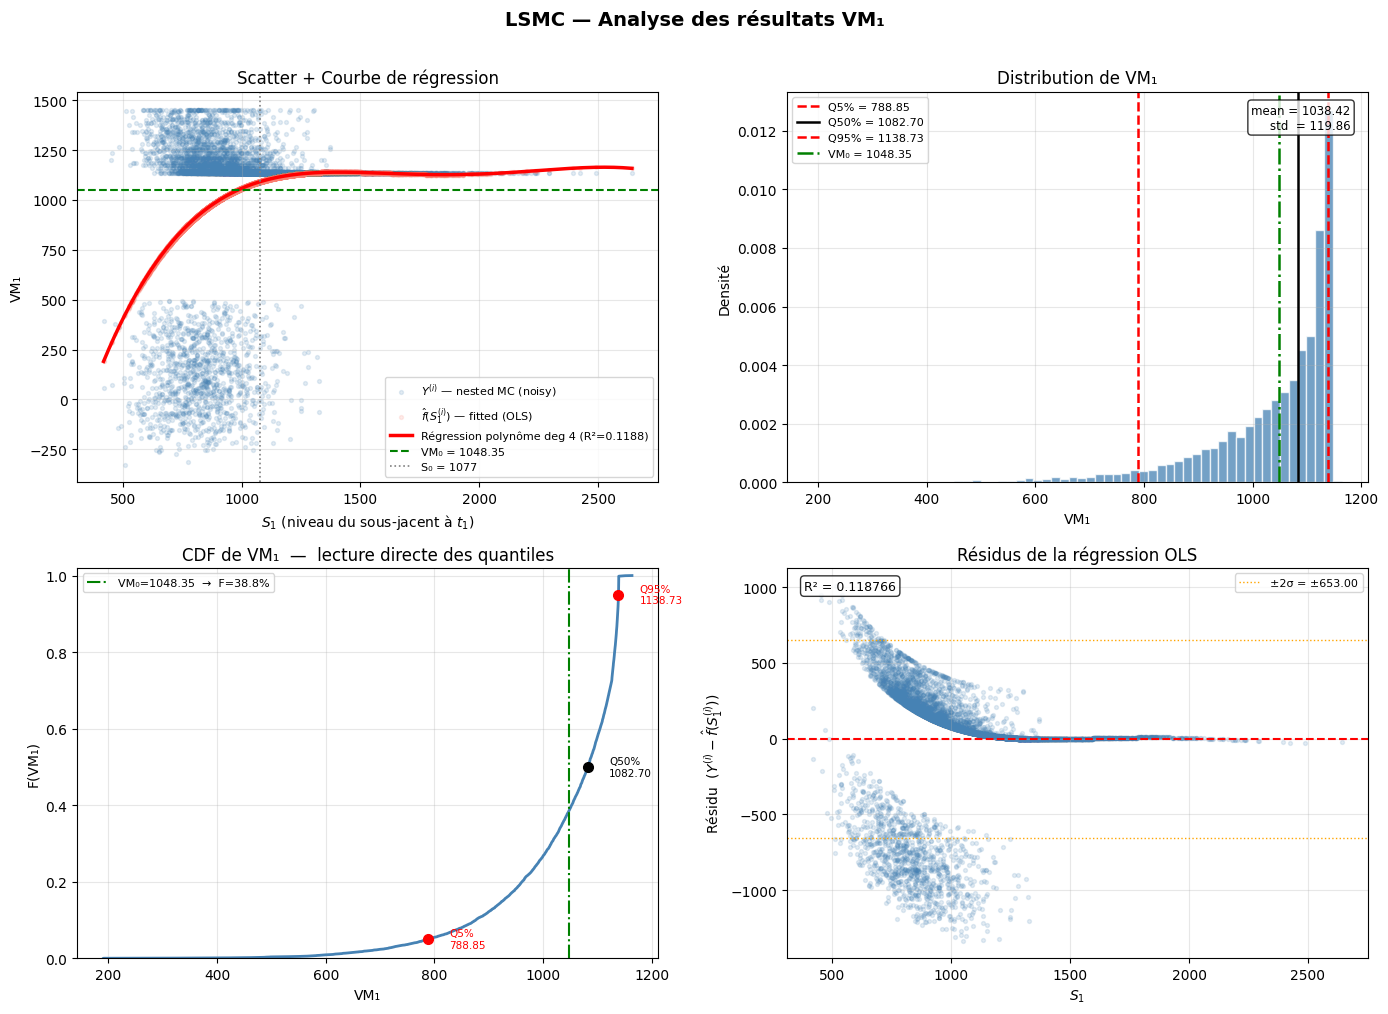

✓ Figure sauvegardée : lsmc_diagnostic.png


In [0]:

plot_lsmc_results(result, vm0=VM0, s0_t0=S0_T0)

Comparaison des degrés polynomiaux — AIC / BIC / R²
 degree  k       R2          RSS       AIC       BIC
      4  5 0.118766 1.066022e+09 115778.59 115814.65
      5  6 0.118823 1.065953e+09 115779.95 115823.21
      6  7 0.118908 1.065850e+09 115780.98 115831.46
      3  4 0.118232 1.066668e+09 115782.65 115811.50
      2  3 0.110024 1.076598e+09 115873.31 115894.94
      1  2 0.075222 1.118697e+09 116254.90 116269.32

  → Meilleur AIC : degré 4
  → Meilleur BIC : degré 3
  → Degré utilisé dans calibrate_lsmc : 4


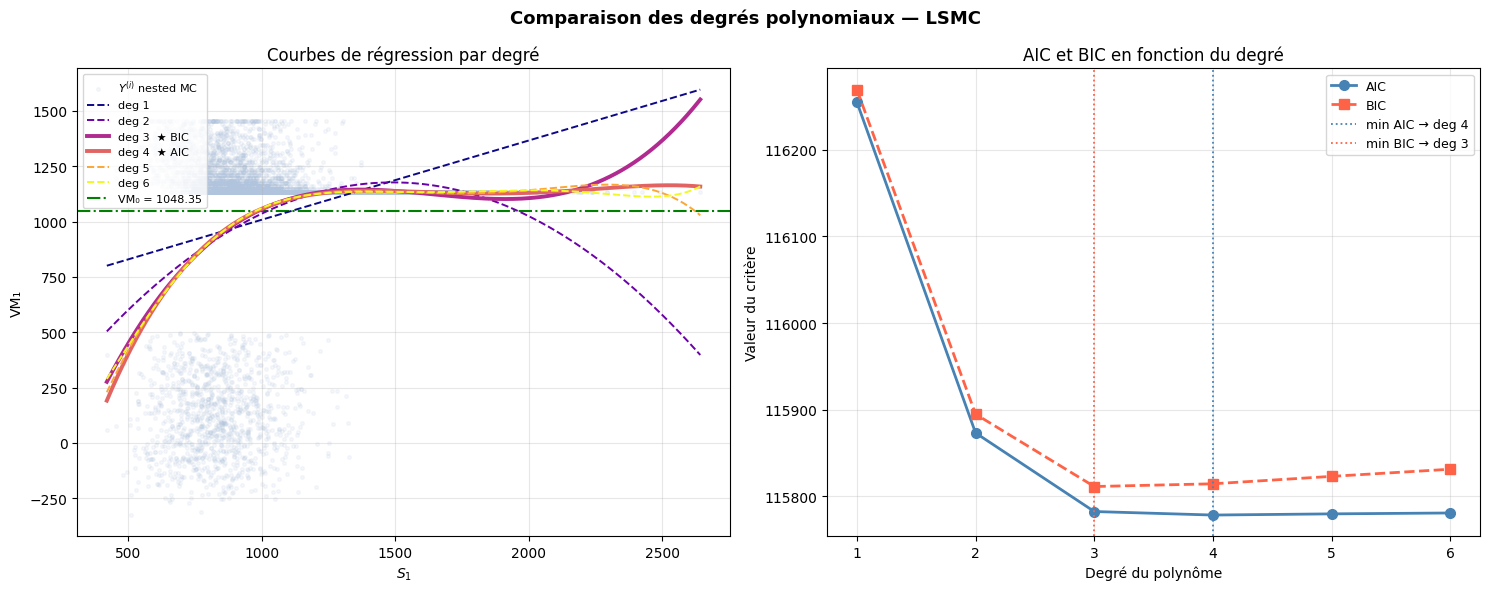

✓ Figure sauvegardée : lsmc_poly_comparison.png


In [0]:
df = compare_poly_lsmc(result, degrees=[1, 2, 3, 4, 5, 6], vm0=VM0)

In [0]:
df

,degree,k,R2,RSS,AIC,BIC
0,4,5,0.118766,1.066022e+09,115778.59,115814.65
1,5,6,0.118823,1.065953e+09,115779.95,115823.21
2,6,7,0.118908,1.065850e+09,115780.98,115831.46
3,3,4,0.118232,1.066668e+09,115782.65,115811.50
4,2,3,0.110024,1.076598e+09,115873.31,115894.94
5,1,2,0.075222,1.118697e+09,116254.90,116269.32


In [0]:
print("╔══════════════════════════════════════════════════════╗")
print("║         SYNTHÈSE — Valorisation LSMC                ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Produit       : {str(row['Libelle']):<36}║")
print(f"║  S_ref         : {S_REF:<36.1f}║")
print(f"║  S₀(t₀)       : {S0_T0:<36.4f}║")
print(f"║  t₀ → t₁      : {str(DATE_VAL_T0.date())+' → '+str(DATE_VAL_T1.date()):<36}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  VM₀           : {VM0:<36.4f}║")
print(f"║  VM₁ moyenne   : {vm1_lsmc.mean():<36.4f}║")
print(f"║  VM₁ médiane   : {q50:<36.4f}║")
print(f"║  VM₁ std       : {vm1_lsmc.std():<36.4f}║")
print(f"║  VM₁ Q5%       : {q5:<36.4f}║")
print(f"║  VM₁ Q95%      : {q95:<36.4f}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  R² régression : {R2:<36.6f}║")
print(f"║  P × K         : {N_OUTER*N_INNER:<36,}║")
print("╚══════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════╗
║         SYNTHÈSE — Valorisation LSMC                ║
╠══════════════════════════════════════════════════════╣


---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File <command-5024114003350038>, line 4
      2 print("║         SYNTHÈSE — Valorisation LSMC                ║")
      3 print("╠══════════════════════════════════════════════════════╣")
----> 4 print(f"║  Produit       : {str(row['Libelle']):<36}║")
      5 print(f"║  S_ref         : {S_REF:<36.1f}║")
      6 print(f"║  S₀(t₀)       : {S0_T0:<36.4f}║")

KeyError: 'Libelle'

### Points clés pour le mémoire

**1. Distinction mesure P / mesure Q**  
Les outer paths sont simulés sous la mesure physique $\mathbb{P}$ (drift $\mu$), car ils représentent les états du monde réels à $t=1$ dans le cadre ORSA. Les inner paths sont toujours sous $\mathbb{Q}$ (drift $r$) car ils servent au pricing.

**2. Rôle du `offset_periods` dans le décrement**  
Sans cet offset, les inner paths remettraient le décrement à zéro à $t=1$, ce qui serait une erreur de modélisation. L'offset assure la continuité du décrement depuis $t_0$.

**3. Qualité de la régression (R²)**  
Un $R^2 \geq 0.95$ indique que le polynôme capture bien la relation $\text{VM}_1 = f(S_1)$. Si $R^2$ est plus faible, augmenter le degré ou $N_{\text{inner}}$.

**4. Interprétation actuarielle (ORSA)**  
- $\mathbb{E}[\text{VM}_1]$ : valeur centrale attendue à $t=1$ pour le business plan  
- $Q_{5\%}[\text{VM}_1]$ : quantile bas utile pour le stress test  
- $\text{std}(\text{VM}_1)$ : mesure de la volatilité de valeur sur 1 an


---
## Section 13 — Validation du modèle sur le portefeuille (37 produits)

Comparaison de $\mathrm{VM}_0^{\text{modèle}}$ (colonne `vm THEORIQUE` de
`Data.xlsx`) à la valeur liquidative observée fournie par l'émetteur
(colonne `valeur liquidative`).

### 13.1 — Préparation des données

In [0]:
# ─── Préparation du jeu de données de validation ──────────────────────
COL_LIBELLE = "Libellé"
COL_VM_THEO = products_df.columns[15]   # "vm THEORIQUE"      — VM0 modèle
COL_VL_OBS  = products_df.columns[14]   # "valeur liquidative" — VL observée
# ⚠️ CORRECTIF : dans les versions précédentes du notebook, ces deux index
# étaient inversés (14 <-> 15), ce qui échangeait VM0_modele et VL_observee
# et faussait le calcul de l'écart relatif (numérateur ET dénominateur
# inversés). Vérifié directement sur Data.xlsx le 24/07/2026.

validation_df = products_df[[COL_LIBELLE, COL_VM_THEO, COL_VL_OBS]].copy()
validation_df.columns = ["Produit", "VM0_modele", "VL_observee"]

# Convert to numeric
validation_df["VL_observee"] = pd.to_numeric(validation_df["VL_observee"], errors='coerce')
validation_df["VM0_modele"]  = pd.to_numeric(validation_df["VM0_modele"],  errors='coerce')

# Supprimer les lignes manquantes
validation_df = validation_df.dropna(subset=["VM0_modele", "VL_observee"])
validation_df = validation_df[validation_df["VL_observee"] > 0]

# ─── Exclusions documentées ────────────────────────────────────────────
# - "Zen Sept, 2022" (index 7 dans products_df) : les colonnes Barriere
#   sortie anticipé / maturité / protection sont vides dans Data.xlsx —
#   ce produit a une structure de payoff différente de l'autocall standard
#   et n'est pas couvert par la fonction Payoff() de ce notebook.
# - "Horizon Monde Déc, 2023" (index 17) : valeur liquidative = 0 — déjà
#   exclu par le filtre VL_observee > 0 ci-dessus ; conservé ici par
#   sécurité/traçabilité si l'ordre des lignes change.
validation_df = validation_df.drop(index=[7, 17], errors="ignore")

# - Exclusion du produit fictif utilisé pour illustrer le Chapitre 1
#   (PRODUIT_LIBELLE) : ce produit n'"'"'a pas de valeur liquidative réellement
#   observée sur le marché ; les valeurs présentes dans Data.xlsx pour cette
#   ligne sont recopiées à des fins d'"'"'affichage et ne doivent PAS entrer dans
#   la validation portefeuille (37 produits réels, Chapitre 5).
validation_df = validation_df[validation_df["Produit"] != PRODUIT_LIBELLE]

# Calcul écarts
validation_df["Ecart_abs"] = validation_df["VM0_modele"] - validation_df["VL_observee"]
validation_df["Ecart_rel"] = (validation_df["Ecart_abs"] / validation_df["VL_observee"]) * 100
validation_df["Ecart_rel_str"] = validation_df["Ecart_rel"].apply(lambda x: f"{x:+.2f}%")

print(f"✓ {len(validation_df)} produits retenus pour la validation")
print()
print(validation_df[["Produit", "VM0_modele", "VL_observee",
                      "Ecart_abs", "Ecart_rel", "Ecart_rel_str"]].to_string(index=False))


✓ 36 produits retenus pour la validation

                   Produit  VM0_modele  VL_observee  Ecart_abs  Ecart_rel Ecart_rel_str
    Itinéraires Sept, 2020  126.761699   126.250000   0.511699   0.405306        +0.41%
    Itinéraires Janv, 2021  124.095190   122.670000   1.425190   1.161808        +1.16%
      Itinéraires Mai 2021  122.902555   117.990000   4.912555   4.163535        +4.16%
    Itinéraires Sept, 2021  118.055444   118.080000  -0.024556  -0.020796        -0.02%
    Itinéraires Janv, 2022  118.180336   117.110000   1.070336   0.913958        +0.91%
      Itinéraires Mai 2022  117.600156   115.120000   2.480156   2.154409        +2.15%
    Itinéraires Sept, 2022  119.392213   117.580000   1.812213   1.541260        +1.54%
    Itinéraires Janv, 2023  121.423911   114.840000   6.583911   5.733116        +5.73%
      Itinéraires Mai 2023  120.678861   116.290000   4.388861   3.774066        +3.77%
    Itinéraires Sept, 2023  121.187633   118.660000   2.527633   2.130148     

### 13.2 — Statistiques descriptives

In [0]:
# ── 3. Statistiques descriptives ───────────────────────────────────────
from scipy import stats as scipy_stats

e = validation_df["Ecart_rel"].values
n = len(e)

mean_e  = e.mean()
med_e   = np.median(e)
std_e   = e.std(ddof=1)
min_e   = e.min()
max_e   = e.max()
pct_5   = (np.abs(e) <= 5).mean() * 100

# Intervalle de confiance à 95% sur la moyenne
ci = scipy_stats.t.interval(0.95, df=n-1,
                             loc=mean_e,
                             scale=scipy_stats.sem(e))

print("=" * 55)
print("  STATISTIQUES DE VALIDATION")
print("=" * 55)
print(f"  Nombre de produits        : {n}")
print(f"  Écart moyen               : {mean_e:+.2f}%")
print(f"  Écart médian              : {med_e:+.2f}%")
print(f"  Écart-type                : {std_e:.2f}%")
print(f"  Écart min                 : {min_e:+.2f}%")
print(f"  Écart max                 : {max_e:+.2f}%")
print(f"  % produits dans [-5%, +5%]: {pct_5:.1f}%")
print(f"  IC 95% sur écart moyen    : [{ci[0]:+.2f}%, {ci[1]:+.2f}%]")
print("=" * 55)

  STATISTIQUES DE VALIDATION
  Nombre de produits        : 36
  Écart moyen               : +1.56%
  Écart médian              : +1.17%
  Écart-type                : 2.64%
  Écart min                 : -4.31%
  Écart max                 : +7.67%
  % produits dans [-5%, +5%]: 86.1%
  IC 95% sur écart moyen    : [+0.67%, +2.45%]


### 13.3 — Figures

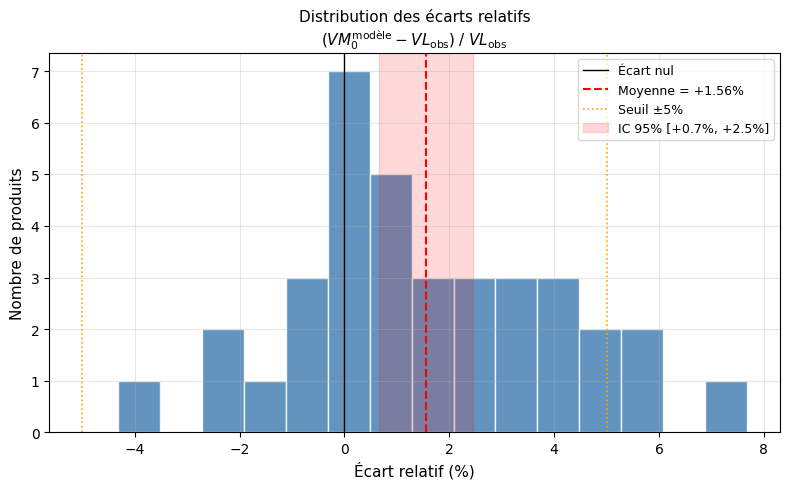

✓ Figure 1 sauvegardée : validation_hist_ecarts.png


In [0]:
# ── Figure 1 — Histogram des écarts ───────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))

ax1.hist(e, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(x=0,      color='black',  linestyle='-',  linewidth=1.0,
            label='Écart nul')
ax1.axvline(x=mean_e, color='red',    linestyle='--', linewidth=1.5,
            label=f'Moyenne = {mean_e:+.2f}%')
ax1.axvline(x=+5,     color='orange', linestyle=':',  linewidth=1.2,
            label='Seuil ±5%')
ax1.axvline(x=-5,     color='orange', linestyle=':',  linewidth=1.2)
ax1.axvspan(ci[0], ci[1], alpha=0.15, color='red',
            label=f'IC 95% [{ci[0]:+.1f}%, {ci[1]:+.1f}%]')

ax1.set_xlabel('Écart relatif (%)', fontsize=11)
ax1.set_ylabel('Nombre de produits', fontsize=11)
ax1.set_title('Distribution des écarts relatifs\n'
              r'$(VM_0^{\mathrm{modèle}} - VL_{\mathrm{obs}}) \;/\; VL_{\mathrm{obs}}$',
              fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("image_p/validation_hist_ecarts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 1 sauvegardée : validation_hist_ecarts.png")

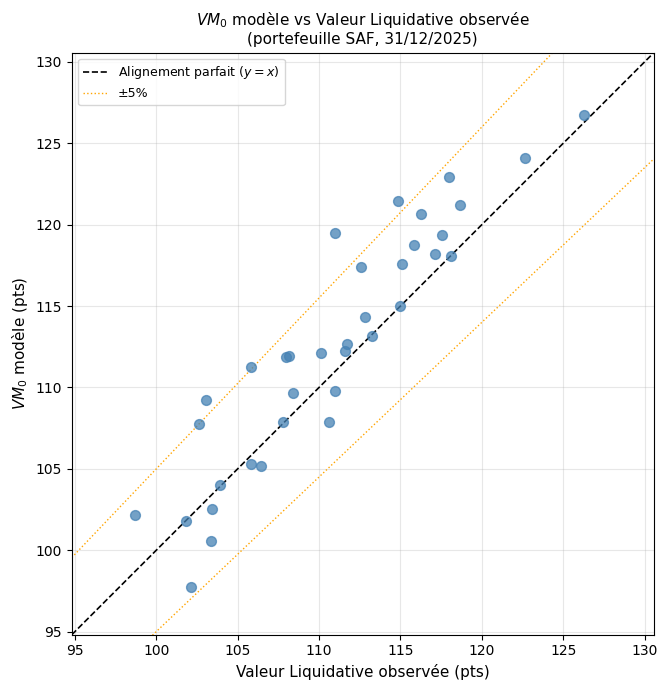

✓ Figure 2 sauvegardée : validation_scatter_vm0.png


In [0]:
# ── Figure 2 — Scatter VM₀ modèle vs VL observée ──────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 7))

ax2.scatter(validation_df["VL_observee"], validation_df["VM0_modele"],
            color='steelblue', alpha=0.75, s=50, zorder=3)

lim_min = min(validation_df["VL_observee"].min(),
              validation_df["VM0_modele"].min()) * 0.97
lim_max = max(validation_df["VL_observee"].max(),
              validation_df["VM0_modele"].max()) * 1.03

# Droite y = x
ax2.plot([lim_min, lim_max], [lim_min, lim_max],
         'k--', linewidth=1.2, label='Alignement parfait ($y = x$)')

# Bandes ±5%
ax2.plot([lim_min, lim_max], [lim_min*1.05, lim_max*1.05],
         color='orange', linestyle=':', linewidth=1.0, label='±5%')
ax2.plot([lim_min, lim_max], [lim_min*0.95, lim_max*0.95],
         color='orange', linestyle=':', linewidth=1.0)

ax2.set_xlabel('Valeur Liquidative observée (pts)', fontsize=11)
ax2.set_ylabel(r'$VM_0$ modèle (pts)', fontsize=11)
ax2.set_title(r'$VM_0$ modèle vs Valeur Liquidative observée'
              '\n(portefeuille SAF, 31/12/2025)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(lim_min, lim_max)
ax2.set_ylim(lim_min, lim_max)
ax2.set_aspect('equal')

plt.tight_layout()
# plt.savefig("image_p/validation_scatter_vm0.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 sauvegardée : validation_scatter_vm0.png")

# Validation avec SdS

Benchmark SdS — 13 points, n_inner_large = 20,000
Coût total ≈ 260,000 trajectoires secondaires
  [ 1/13]  S1=   570.00  (x=0.570)  VM1_SdS =  526.4293   sigma_PV=  615.29
  [ 2/13]  S1=   600.00  (x=0.600)  VM1_SdS =  580.8899   sigma_PV=  618.17
  [ 3/13]  S1=   630.00  (x=0.630)  VM1_SdS =  620.2163   sigma_PV=  612.32
  [ 4/13]  S1=   706.77  (x=0.707)  VM1_SdS =  756.2224   sigma_PV=  585.77
  [ 5/13]  S1=   774.98  (x=0.775)  VM1_SdS =  857.6729   sigma_PV=  538.76
  [ 6/13]  S1=   826.50  (x=0.827)  VM1_SdS =  914.9874   sigma_PV=  495.66
  [ 7/13]  S1=   870.00  (x=0.870)  VM1_SdS =  969.4938   sigma_PV=  448.32
  [ 8/13]  S1=   895.33  (x=0.895)  VM1_SdS =  995.8148   sigma_PV=  416.97
  [ 9/13]  S1=   913.50  (x=0.913)  VM1_SdS = 1005.3908   sigma_PV=  402.98
  [10/13]  S1=  1054.39  (x=1.054)  VM1_SdS = 1087.0262   sigma_PV=  257.47
  [11/13]  S1=  1238.11  (x=1.238)  VM1_SdS = 1126.9444   sigma_PV=  108.25
  [12/13]  S1=  1434.88  (x=1.435)  VM1_SdS = 1134.3841   sigma_PV= 

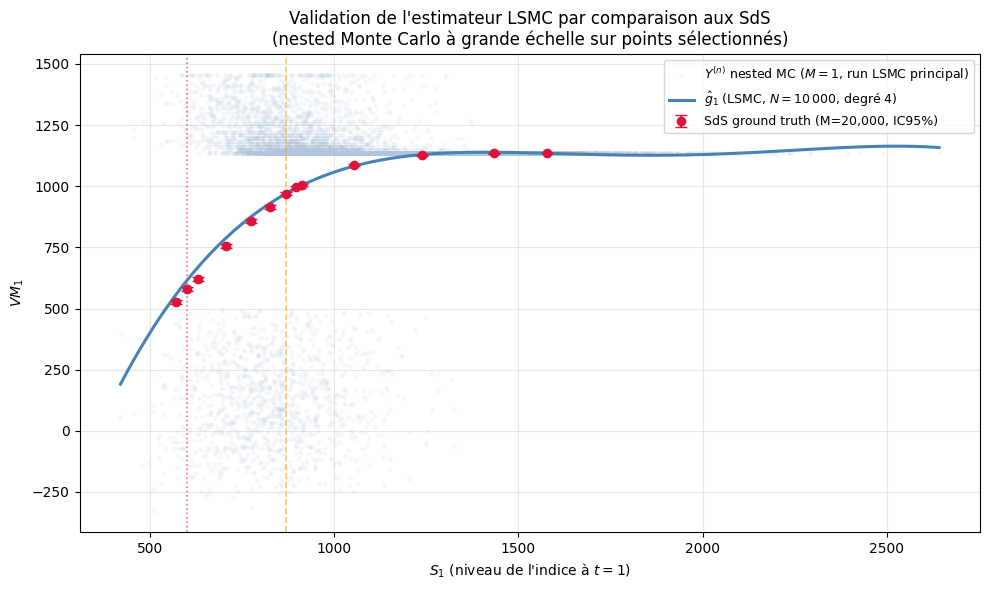

✓ Figure sauvegardée : sds_validation_plot.png


In [0]:
# ═══════════════════════════════════════════════════════════════════════
# VALIDATION LSMC PAR COMPARAISON AUX "SIMULATIONS DANS LES SIMULATIONS"
# ═══════════════════════════════════════════════════════════════════════
#
# Ce script est à insérer dans une NOUVELLE cellule du notebook, APRÈS
# l'exécution de `calibrate_lsmc(...)` (celle qui produit `f_vm1` et
# `result` avec N_OUTER=10_000, N_INNER=1, POLY_DEGREE=4).
#
# Il réutilise EXACTEMENT les fonctions déjà définies dans le notebook :
#   simulate_gbm_monthly, decrement_paths, Payoff, VM, _months_to_reach
# et les variables déjà définies dans les cellules "Paramètres contractuels"
# et "Paramètres de marché" (S_REF, S0_T0, R_NEUTRE_CC, SIGMA_ANNUAL,
# DATE_DEBUT, BARRIERE_AUTOCALL, BARRIERE_FINAL, BARRIERE_PROTECTION,
# PREMIERE_ANNEE_SORTIE, FREQ_SORTIE, COUPON_PAR_PERIODE, ANNEE_FINALE,
# taux_df, DATE_VAL_T0, DATE_VAL_T1, DECREMENT_VAL, DECREMENT_MODE).
#
# Aucune fonction existante n'est modifiée : ce script n'ajoute que du
# code nouveau.
# ═══════════════════════════════════════════════════════════════════════


# ───────────────────────────────────────────────────────────────────────
# 1. Fonction de benchmark SdS (nested Monte Carlo à grande échelle,
#    évalué sur un ensemble RESTREINT de niveaux S1 choisis à l'avance)
# ───────────────────────────────────────────────────────────────────────
def sds_ground_truth(
    s1_targets: np.ndarray,
    # ── Paramètres contractuels (identiques à Payoff) ──────────────────
    date_debut, s_ref, barriere_sortie_anticipe, barriere_sortie_maturite,
    barriere_protection, premiere_annee_sortie, freq_sortie,
    coupon_par_periode, annee_finale,
    # ── Paramètres de marché ───────────────────────────────────────────
    r_neutre_cc, sigma_annual, courbe_taux,
    # ── Dates ───────────────────────────────────────────────────────────
    date_valuation_t0, date_valuation_t1,
    # ── Taille du nested MC "grande échelle" ───────────────────────────
    n_inner_large: int = 20_000,
    # ── Décrement (mesure neutre Q, identique à l'inner de calibrate_lsmc)
    decrement_value_neutre: float = 50.0,
    decrement_mode: str = "cum",
    periods_per_year: int = 12,
    compounding: str = "annual",
    day_count: int = 365,
    seed_base: int = 2026,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Pour chaque niveau S1 cible fourni dans `s1_targets`, calcule une
    estimation "SdS" (Simulations dans les Simulations) de VM1(S1) par
    nested Monte Carlo à grande échelle (n_inner_large trajectoires
    secondaires), servant de référence quasi-exacte pour valider
    l'estimateur LSMC hat_g_1.

    Contrairement à calibrate_lsmc(...), les niveaux S1 ne sont PAS
    simulés aléatoirement sous P : ils sont fixés à l'avance (quantiles
    de la distribution de S1, points proches des barrières, etc.), ce
    qui permet de tester la précision de hat_g_1 exactement là où c'est
    le plus informatif.

    Retourne un DataFrame avec, pour chaque S1 cible :
      - VM1_SdS_mean : moyenne des payoffs actualisés (estimateur SdS)
      - VM1_SdS_std  : écart-type des payoffs actualisés (1 seule trajectoire)
      - SE           : erreur-type de la moyenne = std / sqrt(n_inner_large)
      - IC95_low / IC95_high : intervalle de confiance à 95% sur VM1_SdS_mean
    """
    t0 = pd.to_datetime(date_valuation_t0)
    t1 = pd.to_datetime(date_valuation_t1)
    d0 = pd.to_datetime(date_debut)
    maturity = d0 + pd.DateOffset(years=annee_finale)

    n_months_inner = _months_to_reach(t1, maturity)
    offset_t1 = int(round((t1.year - t0.year) * 12 + (t1.month - t0.month)))

    s1_targets = np.asarray(s1_targets, dtype=float)
    K = len(s1_targets)

    vm1_mean = np.zeros(K)
    vm1_std  = np.zeros(K)

    rng = np.random.default_rng(seed_base)

    if verbose:
        print("=" * 65)
        print(f"Benchmark SdS — {K} points, n_inner_large = {n_inner_large:,}")
        print(f"Coût total ≈ {K * n_inner_large:,} trajectoires secondaires")
        print("=" * 65)

    for k, s1_k in enumerate(s1_targets):
        inner_paths = simulate_gbm_monthly(
            s0=float(s1_k),
            r_annual_cc=r_neutre_cc,
            sigma_annual=sigma_annual,
            start_date=str(t1.date()),
            n_months=n_months_inner,
            n_sims=n_inner_large,
            seed=int(rng.integers(0, 2**31)),
        )
        inner_dec = decrement_paths(
            inner_paths,
            decrement_value=decrement_value_neutre,
            periods_per_year=periods_per_year,
            mode=decrement_mode,
            offset_periods=offset_t1,
        )
        pay_k = Payoff(
            paths=inner_dec,
            date_debut=d0,
            s_ref=float(s_ref),
            barriere_sortie_anticipe=float(barriere_sortie_anticipe),
            barriere_sortie_maturite=float(barriere_sortie_maturite),
            barriere_protection=float(barriere_protection),
            premiere_annee_sortie=int(premiere_annee_sortie),
            freq_sortie=freq_sortie,
            coupon_par_periode=float(coupon_par_periode),
            annee_finale=int(annee_finale),
            day_count=int(day_count),
        )
        tbl_k, vm_k = VM(
            pay_k, courbe_taux, date_valuation=t1,
            compounding=compounding, day_count=day_count,
        )
        pv = tbl_k["PV"].values
        vm1_mean[k] = vm_k
        vm1_std[k] = float(np.std(pv, ddof=1))

        if verbose:
            print(f"  [{k+1:2d}/{K}]  S1={s1_k:9.2f}  (x={s1_k/s_ref:.3f})  "
                  f"VM1_SdS = {vm1_mean[k]:9.4f}   sigma_PV={vm1_std[k]:8.2f}")

    se = vm1_std / np.sqrt(n_inner_large)
    ic_low = vm1_mean - 1.96 * se
    ic_high = vm1_mean + 1.96 * se

    df = pd.DataFrame({
        "S1": s1_targets,
        "x": s1_targets / float(s_ref),
        "VM1_SdS_mean": vm1_mean,
        "VM1_SdS_std": vm1_std,
        "SE": se,
        "IC95_low": ic_low,
        "IC95_high": ic_high,
    }).sort_values("S1").reset_index(drop=True)

    if verbose:
        print("=" * 65)
        print("✓ Benchmark SdS terminé")

    return df


# ───────────────────────────────────────────────────────────────────────
# 2. Sélection des points S1 à tester
#    (quantiles de la distribution réelle de S1 + points proches des
#    barrières, là où la fonction hat_g_1 présente ses points de rupture)
# ───────────────────────────────────────────────────────────────────────
def build_s1_targets(result: dict, s_ref: float,
                      barriere_protection: float, barriere_autocall: float
                      ) -> np.ndarray:
    """
    Construit l'ensemble des niveaux S1 à tester dans le benchmark SdS :
      - quantiles 5/10/25/50/75/90/95% de la distribution de s1_outer
        (issue du run LSMC principal N=10 000, M=1) ;
      - points exactement sur les barrières de protection et d'autocall ;
      - points légèrement de part et d'autre de chaque barrière (±5%),
        pour tester la précision de hat_g_1 au voisinage des points
        de rupture de la fonction de payoff.
    """
    s1_outer = result["s1_outer"]
    quantile_points = np.percentile(s1_outer, [5, 10, 25, 50, 75, 90, 95])

    barrier_points = np.array([
        barriere_protection * s_ref,
        barriere_autocall * s_ref,
    ])
    barrier_neighbors = np.array([
        0.95 * barriere_protection * s_ref, 1.05 * barriere_protection * s_ref,
        0.95 * barriere_autocall * s_ref,   1.05 * barriere_autocall * s_ref,
    ])

    s1_targets = np.unique(np.concatenate(
        [quantile_points, barrier_points, barrier_neighbors]
    ))
    # on retire les points hors du support observé pour éviter l'extrapolation
    s1_targets = s1_targets[
        (s1_targets >= s1_outer.min()) & (s1_targets <= s1_outer.max())
    ]
    return s1_targets


# ───────────────────────────────────────────────────────────────────────
# 3. Exécution du benchmark + comparaison avec hat_g_1 (f_vm1)
#    NOTE : `result` et `f_vm1` doivent provenir de l'appel déjà fait à
#    calibrate_lsmc(...) plus haut dans le notebook.
# ───────────────────────────────────────────────────────────────────────
s1_targets = build_s1_targets(
    result, S_REF, BARRIERE_PROTECTION, BARRIERE_AUTOCALL
)

df_sds = sds_ground_truth(
    s1_targets=s1_targets,
    date_debut=DATE_DEBUT,
    s_ref=S_REF,
    barriere_sortie_anticipe=BARRIERE_AUTOCALL,
    barriere_sortie_maturite=BARRIERE_FINAL,
    barriere_protection=BARRIERE_PROTECTION,
    premiere_annee_sortie=PREMIERE_ANNEE_SORTIE,
    freq_sortie=FREQ_SORTIE,
    coupon_par_periode=COUPON_PAR_PERIODE,
    annee_finale=ANNEE_FINALE,
    r_neutre_cc=R_NEUTRE_CC,
    sigma_annual=SIGMA_ANNUAL,
    courbe_taux=taux_df,
    date_valuation_t0=DATE_VAL_T0,
    date_valuation_t1=DATE_VAL_T1,
    n_inner_large=20_000,
    decrement_value_neutre=DECREMENT_VAL,
    decrement_mode=DECREMENT_MODE,
)

# ── Évaluation de hat_g_1 (LSMC) aux mêmes points S1 ────────────────────
df_sds["VM1_LSMC"] = f_vm1(df_sds["S1"].values)
df_sds["Ecart_absolu"] = df_sds["VM1_LSMC"] - df_sds["VM1_SdS_mean"]
df_sds["Ecart_relatif_%"] = 100 * df_sds["Ecart_absolu"] / df_sds["VM1_SdS_mean"]
df_sds["Dans_IC95_SdS"] = (
    (df_sds["VM1_LSMC"] >= df_sds["IC95_low"]) &
    (df_sds["VM1_LSMC"] <= df_sds["IC95_high"])
)

print("\n" + "=" * 90)
print("TABLEAU DE COMPARAISON  —  LSMC (hat_g_1)  vs  SdS (ground truth)")
print("=" * 90)
cols = ["S1", "x", "VM1_SdS_mean", "IC95_low", "IC95_high",
        "VM1_LSMC", "Ecart_relatif_%", "Dans_IC95_SdS"]
print(df_sds[cols].to_string(index=False,
      formatters={
          "S1": "{:,.2f}".format, "x": "{:.3f}".format,
          "VM1_SdS_mean": "{:,.2f}".format,
          "IC95_low": "{:,.2f}".format, "IC95_high": "{:,.2f}".format,
          "VM1_LSMC": "{:,.2f}".format,
          "Ecart_relatif_%": "{:+.2f}".format,
      }))

taux_couverture = df_sds["Dans_IC95_SdS"].mean()
print(f"\n→ Taux de couverture : {taux_couverture:.1%} des points LSMC "
      f"tombent dans l'IC95% de l'estimation SdS.")
print(f"→ Écart relatif max (valeur absolue) : "
      f"{df_sds['Ecart_relatif_%'].abs().max():.2f}%")
print(f"→ Écart relatif moyen (valeur absolue) : "
      f"{df_sds['Ecart_relatif_%'].abs().mean():.2f}%")

# sauvegarde pour réutilisation ultérieure (LaTeX, etc.)
df_sds.to_csv("sds_validation_results.csv", index=False)
print("\n✓ Résultats sauvegardés dans sds_validation_results.csv")


# ───────────────────────────────────────────────────────────────────────
# 4. Figure : courbe hat_g_1 + points SdS avec barres d'erreur IC95%
# ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Nuage de points bruts (Y nested, M=1) du run LSMC principal — repère visuel
ax.scatter(result["s1_outer"], result["vm1_nested"],
           alpha=0.08, s=6, color="lightsteelblue",
           label=r"$Y^{(n)}$ nested MC ($M=1$, run LSMC principal)", zorder=1)

# Courbe hat_g_1
s1_grid = np.linspace(result["s1_outer"].min(), result["s1_outer"].max(), 400)
ax.plot(s1_grid, f_vm1(s1_grid), color="steelblue", lw=2.2,
         label=r"$\hat{g}_1$ (LSMC, $N=10\,000$, degré 4)", zorder=3)

# Points SdS avec IC95%
ax.errorbar(
    df_sds["S1"], df_sds["VM1_SdS_mean"],
    yerr=1.96 * df_sds["SE"],
    fmt="o", color="crimson", ecolor="crimson", elinewidth=1.5,
    capsize=4, markersize=6, zorder=4,
    label=f"SdS ground truth (M={20_000:,}, IC95%)"
)

# Repères des barrières
ax.axvline(BARRIERE_PROTECTION * S_REF, color="crimson", ls=":", lw=1.2, alpha=0.6)
ax.axvline(BARRIERE_AUTOCALL * S_REF, color="orange", ls="--", lw=1.2, alpha=0.6)

ax.set_xlabel(r"$S_1$ (niveau de l'indice à $t=1$)")
ax.set_ylabel(r"$VM_1$")
ax.set_title("Validation de l'estimateur LSMC par comparaison aux SdS\n"
             "(nested Monte Carlo à grande échelle sur points sélectionnés)")
ax.legend(fontsize=9, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sds_validation_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée : sds_validation_plot.png")

In [0]:
# ─── Sélection des niveaux S1 pour la validation SdS ────────────────────
# Règle (cf. mémoire) : quantiles 5/10/25/50/75/90/95% de la distribution
# empirique de S1 (outer paths sous P, issus de calibrate_lsmc) + points au
# voisinage immédiat (-5%, 0%, +5%) des barrières de protection et d'autocall,
# là où ĝ1 présente un point de rupture. Tout est dérivé des variables du
# produit sélectionné (BARRIERE_PROTECTION, BARRIERE_AUTOCALL) : recalculé
# automatiquement à chaque changement de PRODUIT_LIBELLE / Data.xlsx.

s1_outer = result["s1_outer"]

quantile_levels = [5, 10, 25, 50, 75, 90, 95]
s1_quantiles = np.percentile(s1_outer, quantile_levels)

barriere_prot_level = BARRIERE_PROTECTION * S_REF
barriere_ac_level    = BARRIERE_AUTOCALL * S_REF

voisinage_offsets = [-0.05, 0.00, 0.05]   # ±5% autour de chaque barrière
s1_voisinage = [
    lvl * (1 + o)
    for lvl in (barriere_prot_level, barriere_ac_level)
    for o in voisinage_offsets
]

s1_targets = np.unique(np.round(
    np.concatenate([s1_quantiles, s1_voisinage]), 2
))

print(f"✓ {len(s1_targets)} niveaux S1 retenus pour la validation SdS")
print("  x = S1/S_ref :", np.round(s1_targets / S_REF, 3))
print()

# ─── Calcul de la référence SdS (nested MC à grande échelle) ───────────
sds_df = sds_ground_truth(
    s1_targets               = s1_targets,
    date_debut                = DATE_DEBUT,
    s_ref                     = S_REF,
    barriere_sortie_anticipe  = BARRIERE_AUTOCALL,
    barriere_sortie_maturite  = BARRIERE_FINAL,
    barriere_protection       = BARRIERE_PROTECTION,
    premiere_annee_sortie     = PREMIERE_ANNEE_SORTIE,
    freq_sortie               = FREQ_SORTIE,
    coupon_par_periode        = COUPON_PAR_PERIODE,
    annee_finale              = ANNEE_FINALE,
    r_neutre_cc               = R_NEUTRE_CC,
    sigma_annual              = SIGMA_ANNUAL,
    courbe_taux               = taux_df,
    date_valuation_t0         = DATE_VAL_T0,
    date_valuation_t1         = DATE_VAL_T1,
    n_inner_large             = 20_000,
    decrement_value_neutre    = DECREMENT_VAL,
    decrement_mode            = DECREMENT_MODE,
    periods_per_year          = 12,
    compounding               = COMPOUNDING,
    day_count                 = DAY_COUNT,
    seed_base                 = 2026,
)

# ─── Comparaison avec l'estimation LSMC ĝ1 et mise en forme (tableau) ──
sds_df["g1_hat"]        = f_vm1(sds_df["S1"].values)
sds_df["Ecart_rel_pct"] = (sds_df["g1_hat"] - sds_df["VM1_SdS_mean"]) / sds_df["VM1_SdS_mean"] * 100
sds_df["Largeur_IC95"]  = sds_df["IC95_high"] - sds_df["IC95_low"]

cols = ["x", "VM1_SdS_mean", "IC95_low", "IC95_high", "g1_hat", "Ecart_rel_pct", "Largeur_IC95"]
print(sds_df[cols].round(2).to_string(index=False))
print()
print(f"Écart max (valeur absolue) : {sds_df['Ecart_rel_pct'].abs().max():.2f}%")
print()
print(sds_df[cols].round(2).to_latex(index=False, float_format="%.2f"))


✓ 13 niveaux S1 retenus pour la validation SdS
  x = S1/S_ref : [0.57  0.6   0.63  0.707 0.775 0.826 0.87  0.895 0.914 1.054 1.238 1.435
 1.576]

Benchmark SdS — 13 points, n_inner_large = 20,000
Coût total ≈ 260,000 trajectoires secondaires
  [ 1/13]  S1=   570.00  (x=0.570)  VM1_SdS =  526.4293   sigma_PV=  615.29
  [ 2/13]  S1=   600.00  (x=0.600)  VM1_SdS =  580.8899   sigma_PV=  618.17
  [ 3/13]  S1=   630.00  (x=0.630)  VM1_SdS =  620.2163   sigma_PV=  612.32
  [ 4/13]  S1=   706.77  (x=0.707)  VM1_SdS =  756.2224   sigma_PV=  585.77
  [ 5/13]  S1=   774.98  (x=0.775)  VM1_SdS =  857.6653   sigma_PV=  538.75
  [ 6/13]  S1=   826.50  (x=0.827)  VM1_SdS =  914.9874   sigma_PV=  495.66
  [ 7/13]  S1=   870.00  (x=0.870)  VM1_SdS =  969.4938   sigma_PV=  448.32
  [ 8/13]  S1=   895.33  (x=0.895)  VM1_SdS =  995.7664   sigma_PV=  416.97
  [ 9/13]  S1=   913.50  (x=0.913)  VM1_SdS = 1005.3908   sigma_PV=  402.98
  [10/13]  S1=  1054.39  (x=1.054)  VM1_SdS = 1087.0262   sigma_PV=  257.4